# 13주차_공간 탐색과 문제해결

- 참고자료
- Preview
- 상태 공간
- 맹목 탐색
- 최고 우선 탐색
- A* 알고리즘
- 미니맥스 알고리즘
- 몬테카를로 트리 탐색 알고리즘
- 몬테카를로 트리 탐색을 이용한 게임 인공지능
- 알파고: 컨볼루션 신경망과 강화 학습, 몬테카를로 트리 탐색의 결합
- 참고자료_알파고 논문
---

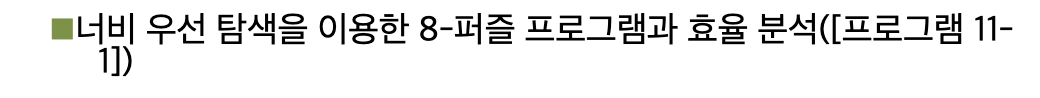

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 고전 인공지능 분야의 대표적인 문제인 8-퍼즐(슬라이딩 퍼즐) 
# 문제를 해결하는 너비 우선 탐색(BFS) 알고리즘을 구현한 예시임.
# 8-퍼즐은 3x3 격자 내 8개의 숫자 타일과 1개의 빈 칸(0)으로 이루어진 상태에서, 
# 각 타일을 상하좌우로 한 칸씩 이동시키며 주어진 초기 상태에서 목표 상태로 바꾸는 최소 이동 경로를 찾는 문제임.
# 퍼즐의 각 상태는 0~8 숫자를 포함한 9자리 문자열로 표현하며, 빈 칸(0)의 위치에 따라 숫자 타일의 상하좌우 이동이 가능함.
# 본 코드는 다음과 같은 핵심 절차를 포함함:
# 1. 퍼즐의 시작 상태와 목표 상태를 문자열로 정의함(퍼즐 상태를 효율적으로 비교 및 기록할 수 있음)
# 2. 현재 퍼즐 상태를 2차원 배열 형태로 시각적으로 출력하는 함수 정의
# 3. 특정 상태에서 빈 칸이 상하좌우로 이동 가능한 모든 후보(자식) 상태를 동적으로 생성하는 함수 정의
# 4. 큐(Queue) 자료구조와 리스트를 이용해 BFS(너비 우선 탐색) 로직 구현: 
#    - 큐에 시작 상태를 삽입하고, 중복 상태 방문을 방지하며, 각 상태에서 가능한 모든 다음 상태를 차례로 탐색함
#    - 목표 상태에 도달하면 탐색을 중단하고, 탐색 과정에서 방문한 전체 노드의 개수를 출력함
# 본 코드는 
# 퍼즐 상태 공간의 탐색 방법, 
# 중복 방문 방지, 
# 최단 해 경로 탐색 등 
# 인공지능·알고리즘 분야의 핵심 개념을 실제 코드에 반영하는 예시임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 퍼즐 초기 설정(시작 상태, 목표 상태, 보드 크기 등)
# 2단계: 퍼즐 상태 출력 함수 정의
# 3단계: 퍼즐 상태에서 이동 가능한 자식 상태(후보) 생성 함수 정의
# 4단계: 너비 우선 탐색(BFS) 메인 루프
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 퍼즐 초기 설정]
# ------------------------------------------------------------
from math import sqrt
# 보드의 한 변 크기를 계산하기 위한 math 모듈 임포트 목적임

from queue import Queue
# 너비 우선 탐색에서 사용할 큐(Queue) 자료구조를 제공하는 queue 모듈 임포트 목적임

start = '806524731'
# 퍼즐의 시작 상태를 9자리 문자열로 지정함. 0은 빈 칸의 위치를 의미함

goal = '123456780'
# 퍼즐의 목표(완성) 상태를 문자열로 정의함

n = int(sqrt(len(goal)))
# 목표 상태 문자열의 길이의 제곱근을 구해 보드의 가로/세로 칸 수로 사용함

# ------------------------------------------------------------
# [2단계: 퍼즐 상태 출력 함수 정의]
# ------------------------------------------------------------
def print_puzzle(p):
    # 퍼즐 상태 p를 2차원 배열 형태로 사람이 읽기 쉽게 출력하는 함수 정의 목적임
    for i in range(n):
        # 각 행 인덱스를 0부터 n-1까지 순회함
        print(p[n*i:n*(i+1)])
        # 퍼즐 상태 문자열에서 현재 행에 해당하는 부분만 잘라서 한 줄로 출력함

# ------------------------------------------------------------
# [3단계: 퍼즐 상태에서 이동 가능한 자식 상태(후보) 생성 함수 정의]
# ------------------------------------------------------------
def Move(p):
    # 현재 퍼즐 상태 p에서 이동 가능한 모든 자식 상태(후보)를 리스트로 반환하는 함수 정의 목적임
    i = p.index('0')
    # 빈 칸(0)의 인덱스 위치를 구함. 이동의 기준점이 됨

    child = []
    # 이동 결과로 생성되는 자식 상태들을 저장할 리스트 선언 목적임

    if not (i % n == 0):
        # 빈 칸이 좌측 끝이 아닐 때(왼쪽 이동 가능 시) 조건 판단임
        child.append(p[:i-1] + p[i] + p[i-1] + p[i+1:])
        # 왼쪽 칸과 빈 칸(0)을 교환한 새로운 상태를 생성하여 후보 리스트에 추가함

    if not (i % n == n-1):
        # 빈 칸이 우측 끝이 아닐 때(오른쪽 이동 가능 시) 조건 판단임
        child.append(p[:i] + p[i+1] + p[i] + p[i+2:])
        # 오른쪽 칸과 빈 칸(0)을 교환한 새로운 상태를 후보 리스트에 추가함

    if i >= n:
        # 빈 칸이 맨 위 행이 아닐 때(위로 이동 가능 시) 조건 판단임
        child.append(p[:i-n] + p[i] + p[i-n+1:i] + p[i-n] + p[i+1:])
        # 위쪽 칸과 빈 칸(0)을 교환한 새로운 상태를 후보 리스트에 추가함

    if i < n * n - n:
        # 빈 칸이 맨 아래 행이 아닐 때(아래로 이동 가능 시) 조건 판단임
        child.append(p[:i] + p[i+n] + p[i+1:i+n] + p[i] + p[i+n+1:])
        # 아래쪽 칸과 빈 칸(0)을 교환한 새로운 상태를 후보 리스트에 추가함

    return child
    # 생성된 모든 자식 상태(후보) 리스트를 반환함

# ------------------------------------------------------------
# [4단계: 너비 우선 탐색(BFS) 메인 루프]
# ------------------------------------------------------------
print_puzzle(start)
# 시작 퍼즐 상태를 2차원 배열 형태로 출력하여 초기 상태를 확인함

Q = Queue()
# BFS 탐색에서 사용할 큐(Queue) 객체를 생성함

Q.put(start)
# 시작 상태(루트 노드)를 큐에 삽입하여 탐색의 시작점으로 지정함

V = [start]
# 방문한 퍼즐 상태(중복 방지 목적)를 저장할 리스트를 생성함. 시작 상태를 먼저 포함함

while not Q.empty():
    # 큐가 빌 때까지(즉, 탐색할 상태가 남아있는 동안) 반복 수행함
    node = Q.get()
    # 큐에서 가장 먼저 들어온 퍼즐 상태(노드)를 꺼내어 현재 탐색 대상으로 사용함
    if node == goal:
        # 현재 상태가 목표 상태와 일치하는지 확인함
        print(len(V), "개 노드를 방문하고 답을 찾았다.")
        # 목표 상태에 도달했으면 방문한 노드 개수와 함께 성공 메시지를 출력함
        break
        # 탐색 루프를 즉시 종료함
    else:
        # 목표 상태가 아니라면
        child = Move(node)
        # 현재 상태에서 이동 가능한 모든 자식 상태(후보) 리스트를 구함
        for j in range(len(child)):
            # 각 자식 상태를 순회하면서
            if child[j] not in V:
                # 해당 자식 상태가 아직 방문한 적이 없는 경우에만 처리함(중복 탐색 방지 목적)
                Q.put(child[j])
                # 새 상태를 큐에 추가하여 다음 탐색 대상으로 등록함
                V.append(child[j])
                # 방문한 상태 리스트에도 추가하여 이후 중복 방문을 방지함


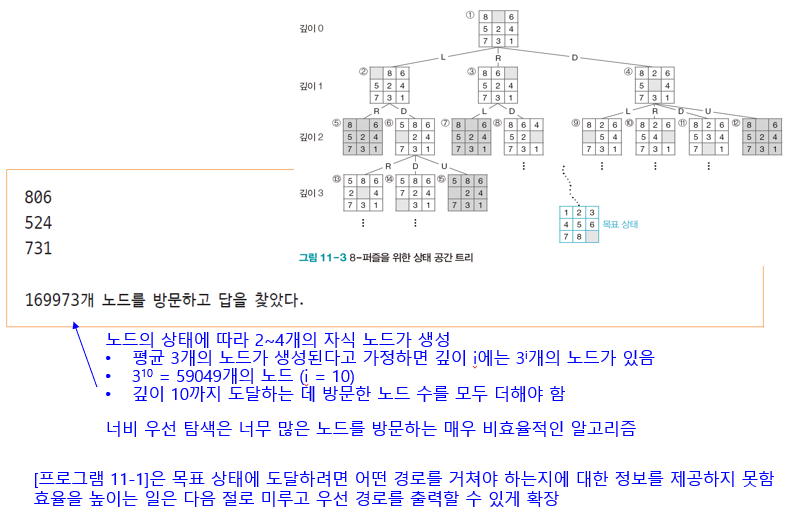

---

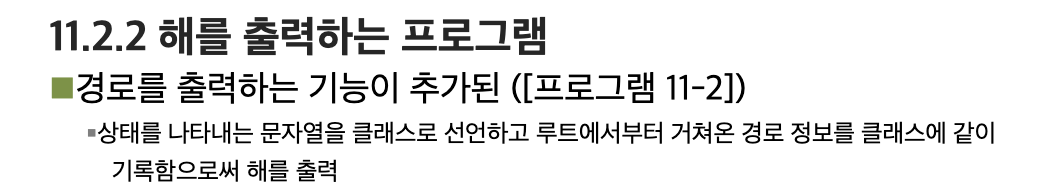

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 8-퍼즐(슬라이딩 퍼즐) 문제를 해결하기 위한 너비 우선 탐색(BFS) 알고리즘 구현 예시임.
# 퍼즐 상태를 문자열로 표현하며, Node 클래스를 이용해 각 퍼즐 상태와 해당 상태까지 도달한 이동 경로(문자열)를 함께 저장함.
# 각 노드의 상태에서 가능한 모든 다음 상태(자식 노드)를 생성할 때 이동 방향(L, R, U, D)을 path에 누적함.
# 큐(Queue) 자료구조를 이용해 탐색 순서를 관리하고, 중복 상태 방문을 방지함으로써 최단 경로로 목표 상태까지의 경로와 이동 횟수를 출력함.
# 핵심 구현 요소로는:  
#   - 시작/목표 상태 및 보드 크기 자동 산출  
#   - Node 클래스(상태+경로)  
#   - 상태별 2차원 시각화 출력  
#   - 이동 후보 생성(Move) 함수  
#   - BFS 루프 및 해 경로(방향 문자열) 출력까지 모두 포함함
# 본 구조는 경로 복원, 상태 표현, 탐색 효율 등 실전 알고리즘 설계와 인공지능 기초를 함께 학습하는데 적합함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 퍼즐 초기 설정(시작/목표 상태, 보드 크기 등)
# 2단계: 상태+경로 저장 Node 클래스 정의
# 3단계: 퍼즐 상태 출력 함수 정의
# 4단계: 자식 노드(후보) 생성 함수 정의
# 5단계: 너비 우선 탐색(BFS) 루프 및 해답 출력
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 퍼즐 초기 설정]
# ------------------------------------------------------------
from math import sqrt
# 보드 크기 계산(제곱근)을 위해 math 모듈 임포트함

from queue import Queue
# BFS 탐색에 사용할 큐(Queue) 자료구조를 임포트함

start = '806524731'
# 퍼즐의 시작 상태를 9자리 문자열로 지정함. 0은 빈 칸의 위치를 의미함

goal = '123456780'
# 퍼즐의 목표 상태(완성 상태)를 문자열로 정의함

n = int(sqrt(len(goal)))
# 목표 상태 문자열의 길이의 제곱근을 구하여 보드의 가로/세로 칸 수로 사용함

# ------------------------------------------------------------
# [2단계: 상태+경로 저장 Node 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, path):
        self.state = state
        # 현재 퍼즐 상태(문자열)를 저장함
        self.path = path
        # 해당 상태에 도달하기까지의 이동 경로(방향 문자열 누적)를 저장함

# ------------------------------------------------------------
# [3단계: 퍼즐 상태 2차원 출력 함수 정의]
# ------------------------------------------------------------
def print_puzzle(state):
    # 퍼즐 상태 문자열을 2차원 배열 형태로 사람이 읽기 쉽게 출력하는 함수 정의 목적임
    for i in range(n):
        print(state[n*i:n*(i+1)])
        # 퍼즐 상태 문자열에서 현재 행에 해당하는 부분만 잘라서 한 줄로 출력함

# ------------------------------------------------------------
# [4단계: 자식 노드(후보) 생성 함수 정의]
# ------------------------------------------------------------
def Move(node):
    # 입력 node에서 이동 가능한 모든 자식 노드(상태+경로)를 리스트로 반환하는 함수 정의임
    p = node.state
    # 현재 노드의 퍼즐 상태 문자열을 p에 저장함
    i = p.index('0')
    # 빈 칸(0)의 인덱스 위치를 구함. 이동의 기준점이 됨
    child = []
    # 생성될 자식 노드를 저장할 리스트 선언임

    if not (i % n == 0):
        # 빈 칸이 좌측 끝이 아닐 때(왼쪽 이동 가능 시) 조건 판단임
        q = p[:i-1] + p[i] + p[i-1] + p[i+1:]
        # 왼쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'L'))
        # 새 상태 q와 이동 경로에 'L'을 추가한 Node 객체를 리스트에 추가함

    if not (i % n == n-1):
        # 빈 칸이 우측 끝이 아닐 때(오른쪽 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+1] + p[i] + p[i+2:]
        # 오른쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'R'))
        # 새 상태 q와 이동 경로에 'R'을 추가한 Node 객체를 리스트에 추가함

    if i >= n:
        # 빈 칸이 맨 위 행이 아닐 때(위로 이동 가능 시) 조건 판단임
        q = p[:i-n] + p[i] + p[i-n+1:i] + p[i-n] + p[i+1:]
        # 위쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'U'))
        # 새 상태 q와 이동 경로에 'U'를 추가한 Node 객체를 리스트에 추가함

    if i < n*n-n:
        # 빈 칸이 맨 아래 행이 아닐 때(아래로 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+n] + p[i+1:i+n] + p[i] + p[i+n+1:]
        # 아래쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'D'))
        # 새 상태 q와 이동 경로에 'D'를 추가한 Node 객체를 리스트에 추가함

    return child
    # 생성된 모든 자식 노드 리스트를 반환함

# ------------------------------------------------------------
# [5단계: BFS 루프 및 해답 출력]
# ------------------------------------------------------------
print_puzzle(start)
# 시작 퍼즐 상태를 2차원 형태로 출력하여 초기 상태를 시각적으로 확인함

Q = Queue()
# BFS 탐색에 사용할 큐(Queue) 객체를 생성함

root = Node(start, '-')
# 시작 상태와 경로('-')를 가지는 Node 객체를 루트로 생성함

Q.put(root)
# 루트 노드를 큐에 삽입하여 탐색의 시작점으로 지정함

V = [root.state]
# 방문한 퍼즐 상태(중복 방지 목적)를 저장할 리스트를 생성함. 시작 상태를 포함함

while not Q.empty():
    # 큐가 빌 때까지(즉, 탐색할 노드가 남아있는 동안) 반복 수행함
    node = Q.get()
    # 큐에서 가장 먼저 들어온 Node 객체를 꺼내어 현재 탐색 대상으로 사용함

    if node.state == goal:
        # 현재 노드의 퍼즐 상태가 목표 상태와 일치하는지 확인함
        print(len(V), '개 노드를 살피고 찾았다!')
        # 목표 상태에 도달했으면 방문한 노드 개수와 함께 성공 메시지를 출력함
        break
        # 탐색 루프를 즉시 종료함

    else:
        # 목표 상태가 아니라면
        child = Move(node)
        # 현재 노드에서 이동 가능한 모든 자식 노드 리스트를 구함

        for j in range(len(child)):
            # 각 자식 노드를 순회하면서
            if child[j].state not in V:
                # 해당 자식 상태가 아직 방문한 적이 없는 경우에만 처리함(중복 탐색 방지 목적)
                Q.put(child[j])
                # 자식 노드를 큐에 추가하여 다음 탐색 대상으로 등록함
                V.append(child[j].state)
                # 방문한 상태 리스트에도 추가하여 이후 중복 방문을 방지함

print(node.path, "(", len(node.path)-1, ")")
# 목표 상태에 도달한 마지막 노드의 이동 경로 문자열과 이동 횟수(문자 개수-1)를 함께 출력함


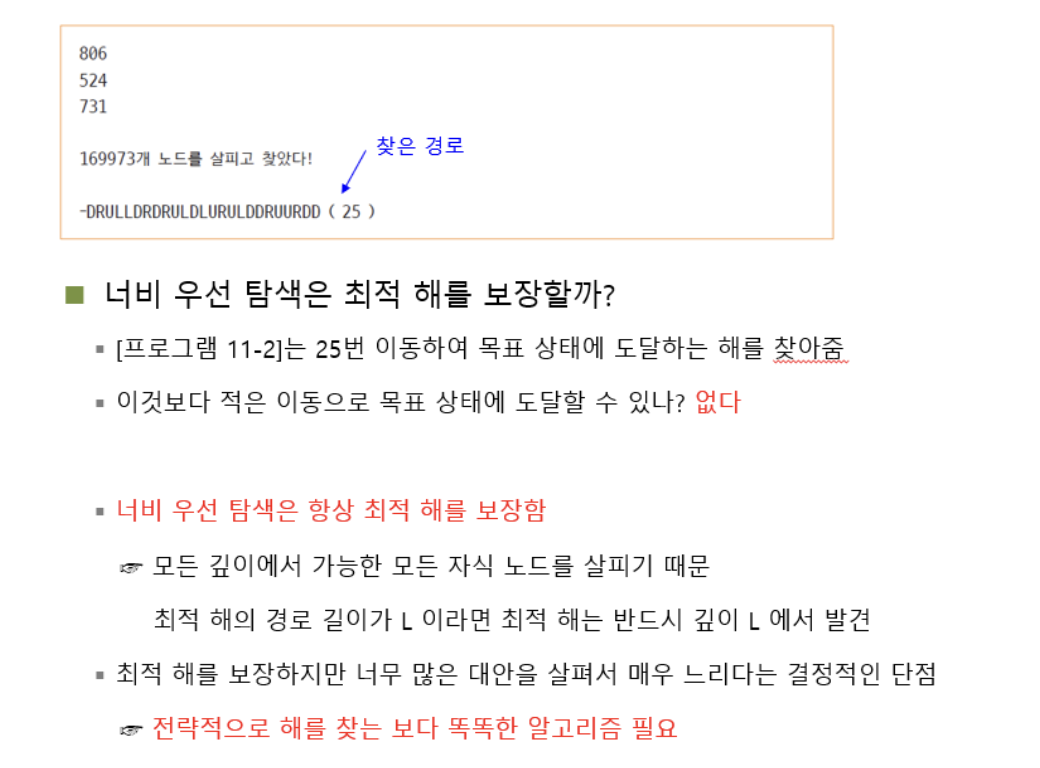

---

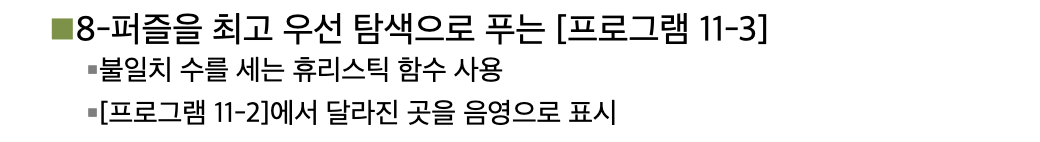

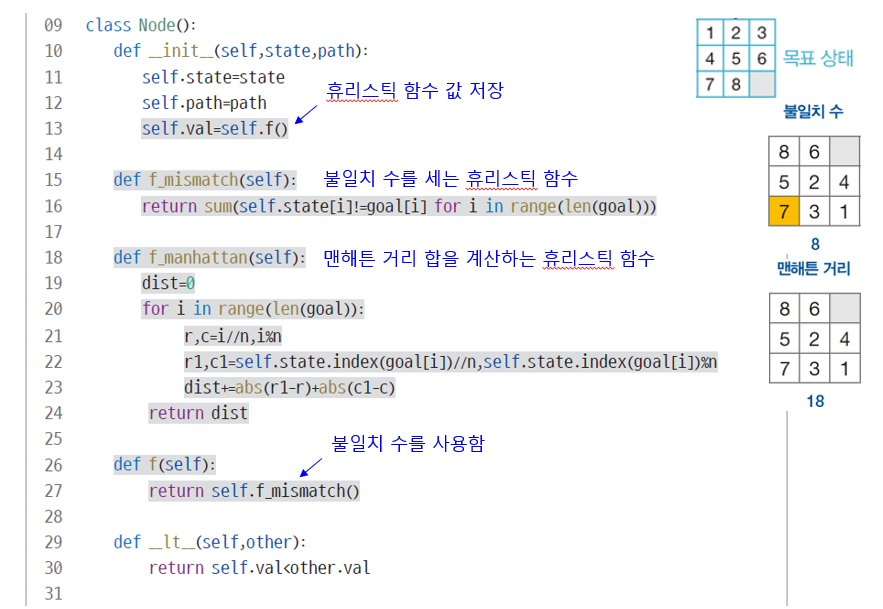
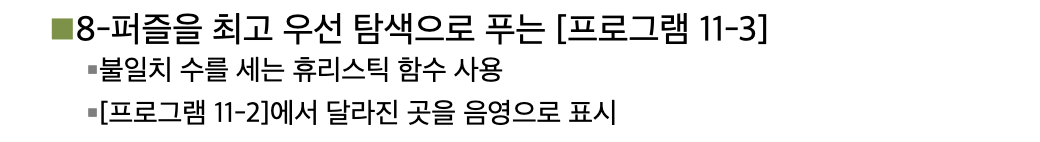

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 8-퍼즐(슬라이딩 퍼즐) 문제를 해결하기 위한 휴리스틱 기반 탐색 알고리즘 구현 예시임.
# 각 퍼즐 상태는 Node 클래스로 관리되며, Node는 퍼즐 상태(state), 이동 경로(path), 휴리스틱 값(val)을 보유함.
# f_mismatch(불일치 개수) 또는 f_manhattan(맨해튼 거리) 휴리스틱을 선택하여 우선순위 큐(PriorityQueue)에서 더 좋은 경로를 우선 탐색함.
# Move 함수는 각 상태에서 가능한 자식 상태를 생성하며, 탐색 루프에서는 중복 상태 방문을 방지함.
# 목표 상태에 도달하면 이동 경로와 이동 횟수를 출력하며, 인공지능 탐색의 실전 구현(휴리스틱, 우선순위 탐색, 경로 추적 등)을 모두 포함함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 퍼즐 초기 설정(시작/목표 상태, 보드 크기 등)
# 2단계: 상태+경로+휴리스틱 저장 Node 클래스 정의
# 3단계: 퍼즐 상태 출력 함수 정의
# 4단계: 자식 노드(후보) 생성 함수 정의
# 5단계: 우선순위 큐 기반 휴리스틱 탐색 루프 및 해답 출력
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 퍼즐 초기 설정]
# ------------------------------------------------------------
from math import sqrt
# 보드 크기 계산(제곱근)을 위해 math 모듈을 임포트함

from queue import PriorityQueue
# 휴리스틱 기반 탐색을 위해 우선순위 큐(PriorityQueue) 자료구조를 임포트함

start = '806524731'
# 퍼즐의 시작 상태를 9자리 문자열로 지정함. 0은 빈 칸의 위치를 의미함

goal = '123456780'
# 퍼즐의 목표 상태(완성 상태)를 문자열로 정의함

n = int(sqrt(len(goal)))
# 목표 상태 문자열의 길이의 제곱근을 구하여 보드의 가로/세로 칸 수로 사용함

# ------------------------------------------------------------
# [2단계: 상태+경로+휴리스틱 저장 Node 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, path):
        self.state = state
        # 현재 퍼즐 상태(문자열)를 저장함
        self.path = path
        # 현재 상태에 도달하기까지의 이동 경로(방향 문자열 누적)를 저장함
        self.val = self.f()
        # 이 노드의 휴리스틱 값을 계산하여 val에 저장함(우선순위 큐에서 사용함)

    def f_mismatch(self):
        # 상태 불일치 개수 휴리스틱 함수(맨 앞부터 비교, 다르면 1씩 가산) 정의임
        return sum(self.state[i] != goal[i] for i in range(len(goal)))
        # 각 자리의 숫자가 목표 상태와 다르면 1씩 합산하여 반환함

    def f_manhattan(self):
        # 맨해튼 거리 휴리스틱 함수 정의임
        dist = 0
        # 총 거리를 누적할 변수 선언임
        for i in range(len(goal)):
            # 목표 상태의 각 숫자에 대해 순회함
            r, c = i // n, i % n
            # 목표 상태에서의 행, 열 좌표 계산임
            r1, c1 = self.state.index(goal[i]) // n, self.state.index(goal[i]) % n
            # 현재 상태에서 해당 숫자의 위치(행, 열) 계산임
            dist += abs(r1 - r) + abs(c1 - c)
            # 행 차이와 열 차이의 합(맨해튼 거리)을 누적함
        return dist
        # 전체 맨해튼 거리 합을 반환함

    def f(self):
        # 사용할 휴리스틱 함수 선택 구간임(현재는 f_mismatch)
        return self.f_mismatch()
        # 휴리스틱 값으로 불일치 개수를 사용함(원하면 f_manhattan으로 교체 가능함)

    def __lt__(self, other):
        # PriorityQueue에서 Node 간 비교 연산 정의임
        return self.val < other.val
        # 휴리스틱 값이 작은 노드가 더 높은 우선순위를 가짐

# ------------------------------------------------------------
# [3단계: 퍼즐 상태 2차원 출력 함수 정의]
# ------------------------------------------------------------
def print_puzzle(state):
    # 퍼즐 상태 문자열을 2차원 배열 형태로 사람이 읽기 쉽게 출력하는 함수 정의임
    for i in range(n):
        print(state[n*i:n*(i+1)])
        # 퍼즐 상태 문자열에서 현재 행에 해당하는 부분만 잘라서 한 줄로 출력함

# ------------------------------------------------------------
# [4단계: 자식 노드(후보) 생성 함수 정의]
# ------------------------------------------------------------
def Move(node):
    # 입력 node에서 이동 가능한 모든 자식 노드(상태+경로)를 리스트로 반환하는 함수 정의임
    p = node.state
    # 현재 노드의 퍼즐 상태 문자열을 p에 저장함
    i = p.index('0')
    # 빈 칸(0)의 인덱스 위치를 구함. 이동 기준점이 됨
    child = []
    # 생성될 자식 노드를 저장할 리스트 선언임

    if not (i % n == 0):
        # 빈 칸이 좌측 끝이 아닐 때(왼쪽 이동 가능 시) 조건 판단임
        q = p[:i-1] + p[i] + p[i-1] + p[i+1:]
        # 왼쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'L'))
        # 새 상태 q와 이동 경로에 'L'을 추가한 Node 객체를 리스트에 추가함

    if not (i % n == n-1):
        # 빈 칸이 우측 끝이 아닐 때(오른쪽 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+1] + p[i] + p[i+2:]
        # 오른쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'R'))
        # 새 상태 q와 이동 경로에 'R'을 추가한 Node 객체를 리스트에 추가함

    if i >= n:
        # 빈 칸이 맨 위 행이 아닐 때(위로 이동 가능 시) 조건 판단임
        q = p[:i-n] + p[i] + p[i-n+1:i] + p[i-n] + p[i+1:]
        # 위쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'U'))
        # 새 상태 q와 이동 경로에 'U'를 추가한 Node 객체를 리스트에 추가함

    if i < n * n - n:
        # 빈 칸이 맨 아래 행이 아닐 때(아래로 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+n] + p[i+1:i+n] + p[i] + p[i+n+1:]
        # 아래쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'D'))
        # 새 상태 q와 이동 경로에 'D'를 추가한 Node 객체를 리스트에 추가함

    return child
    # 생성된 모든 자식 노드 리스트를 반환함

# ------------------------------------------------------------
# [5단계: 우선순위 큐 기반 휴리스틱 탐색 루프 및 해답 출력]
# ------------------------------------------------------------
print_puzzle(start)
# 시작 퍼즐 상태를 2차원 형태로 출력하여 초기 상태를 시각적으로 확인함

Q = PriorityQueue()
# 우선순위 큐(PriorityQueue) 객체를 생성함

root = Node(start, '-')
# 시작 상태와 경로('-')를 가지는 Node 객체를 루트로 생성함

Q.put(root)
# 루트 노드를 큐에 삽입하여 탐색의 시작점으로 지정함

V = [root.state]
# 방문한 퍼즐 상태(중복 방지 목적)를 저장할 리스트를 생성함. 시작 상태를 포함함

while not Q.empty():
    # 큐가 빌 때까지(즉, 탐색할 노드가 남아있는 동안) 반복 수행함
    node = Q.get()
    # 큐에서 휴리스틱 값이 가장 낮은 Node 객체를 꺼내어 현재 탐색 대상으로 사용함

    if node.state == goal:
        # 현재 노드의 퍼즐 상태가 목표 상태와 일치하는지 확인함
        print(len(V), '개 노드를 살피고 찾았다!')
        # 목표 상태에 도달했으면 방문한 노드 개수와 함께 성공 메시지를 출력함
        break
        # 탐색 루프를 즉시 종료함

    else:
        # 목표 상태가 아니라면
        child = Move(node)
        # 현재 노드에서 이동 가능한 모든 자식 노드 리스트를 구함

        for j in range(len(child)):
            # 각 자식 노드를 순회하면서
            if child[j].state not in V:
                # 해당 자식 상태가 아직 방문한 적이 없는 경우에만 처리함(중복 탐색 방지 목적)
                Q.put(child[j])
                # 자식 노드를 우선순위 큐에 추가하여 다음 탐색 대상으로 등록함
                V.append(node.state)
                # 방문한 상태 리스트에도 추가하여 이후 중복 방문을 방지함

print(node.path, "(", len(node.path)-1, ")")
# 목표 상태에 도달한 마지막 노드의 이동 경로 문자열과 이동 횟수(문자 개수-1)를 함께 출력함


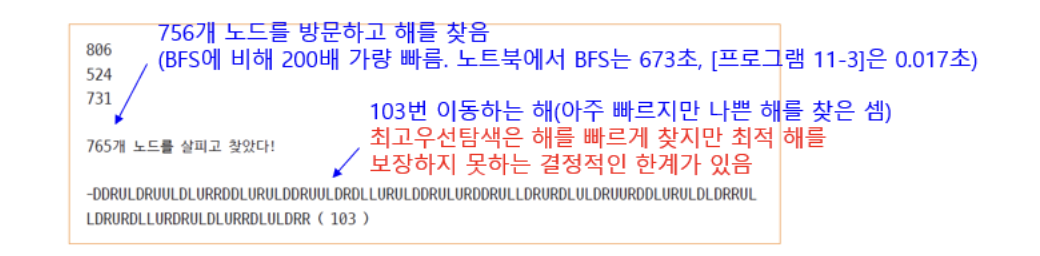

---

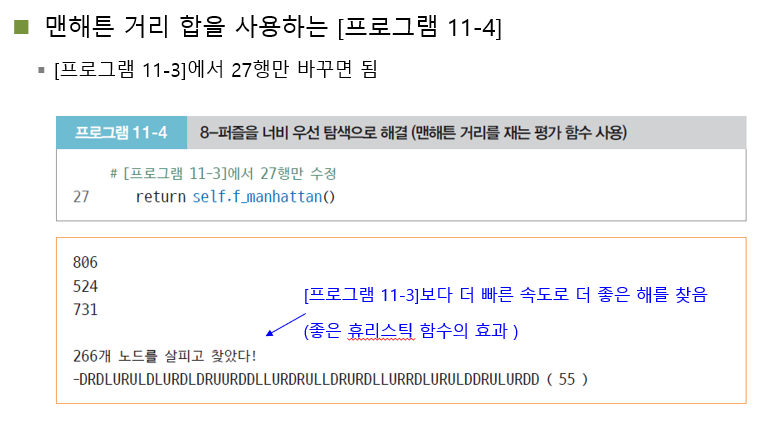

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 8-퍼즐(슬라이딩 퍼즐) 문제를 해결하는 맨해튼 거리 기반 우선순위 탐색(Priority Queue) 알고리즘의 대표 예시임.
# 각 퍼즐 상태는 Node 클래스의 인스턴스로 표현되며, Node는 상태(state), 이동 경로(path), 휴리스틱 값(val)을 저장함.
# f_manhattan() 함수에서 맨해튼 거리(각 숫자가 목표 위치까지 가야 하는 거리의 총합)를 계산하여 탐색 우선순위로 활용함.
# Move 함수는 현재 상태에서 빈 칸을 상하좌우로 움직여 생성 가능한 모든 자식 노드(후보 상태)를 반환함.
# PriorityQueue를 사용해 가장 유망한 경로(휴리스틱 값이 가장 낮은 경로)부터 우선적으로 탐색하며, 중복 상태 방문을 방지함.
# 목표 상태 도달 시 전체 방문 노드 수와 함께 이동 경로, 이동 횟수를 출력함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 퍼즐 초기 설정(시작/목표 상태, 보드 크기)
# 2단계: 상태+경로+휴리스틱 저장 Node 클래스 정의
# 3단계: 퍼즐 상태 출력 함수 정의
# 4단계: 자식 노드(후보) 생성 함수 정의
# 5단계: 우선순위 큐 기반 맨해튼 거리 탐색 루프 및 해답 출력
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 퍼즐 초기 설정]
# ------------------------------------------------------------
from math import sqrt
# 보드 크기 계산(제곱근)을 위해 math 모듈을 임포트함

from queue import PriorityQueue
# 맨해튼 거리 휴리스틱 기반 탐색을 위해 우선순위 큐(PriorityQueue) 자료구조를 임포트함

start = '806524731'
# 퍼즐의 시작 상태를 9자리 문자열로 지정함. 0은 빈 칸의 위치를 의미함

goal = '123456780'
# 퍼즐의 목표 상태(완성 상태)를 문자열로 정의함

n = int(sqrt(len(goal)))
# 목표 상태 문자열의 길이의 제곱근을 구하여 보드의 가로/세로 칸 수로 사용함

# ------------------------------------------------------------
# [2단계: 상태+경로+휴리스틱 저장 Node 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, path):
        self.state = state
        # 현재 퍼즐 상태(문자열)를 저장함
        self.path = path
        # 현재 상태에 도달하기까지의 이동 경로(방향 문자열 누적)를 저장함
        self.val = self.f()
        # 이 노드의 휴리스틱 값을 계산하여 val에 저장함(우선순위 큐에서 사용함)

    def f_mismatch(self):
        # 상태 불일치 개수 휴리스틱 함수 정의임(참고용, 현재는 사용하지 않음)
        return sum(self.state[i] != goal[i] for i in range(len(goal)))
        # 각 자리의 숫자가 목표 상태와 다르면 1씩 합산하여 반환함

    def f_manhattan(self):
        # 맨해튼 거리 휴리스틱 함수 정의임
        dist = 0
        # 총 거리를 누적할 변수 선언임
        for i in range(len(goal)):
            # 목표 상태의 각 숫자에 대해 순회함
            r, c = i // n, i % n
            # 목표 상태에서의 행, 열 좌표 계산임
            r1, c1 = self.state.index(goal[i]) // n, self.state.index(goal[i]) % n
            # 현재 상태에서 해당 숫자의 위치(행, 열) 계산임
            dist += abs(r1 - r) + abs(c1 - c)
            # 행 차이와 열 차이의 합(맨해튼 거리)을 누적함
        return dist
        # 전체 맨해튼 거리 합을 반환함

    def f(self):
        # 사용할 휴리스틱 함수 선택 구간임
        return self.f_manhattan()
        # 휴리스틱 값으로 맨해튼 거리 총합을 사용함

    def __lt__(self, other):
        # PriorityQueue에서 Node 간 비교 연산 정의임
        return self.val < other.val
        # 휴리스틱 값이 작은 노드가 더 높은 우선순위를 가짐

# ------------------------------------------------------------
# [3단계: 퍼즐 상태 2차원 출력 함수 정의]
# ------------------------------------------------------------
def print_puzzle(state):
    # 퍼즐 상태 문자열을 2차원 배열 형태로 사람이 읽기 쉽게 출력하는 함수 정의임
    for i in range(n):
        print(state[n*i:n*(i+1)])
        # 퍼즐 상태 문자열에서 현재 행에 해당하는 부분만 잘라서 한 줄로 출력함

# ------------------------------------------------------------
# [4단계: 자식 노드(후보) 생성 함수 정의]
# ------------------------------------------------------------
def Move(node):
    # 입력 node에서 이동 가능한 모든 자식 노드(상태+경로)를 리스트로 반환하는 함수 정의임
    p = node.state
    # 현재 노드의 퍼즐 상태 문자열을 p에 저장함
    i = p.index('0')
    # 빈 칸(0)의 인덱스 위치를 구함. 이동 기준점이 됨
    child = []
    # 생성될 자식 노드를 저장할 리스트 선언임

    if not (i % n == 0):
        # 빈 칸이 좌측 끝이 아닐 때(왼쪽 이동 가능 시) 조건 판단임
        q = p[:i-1] + p[i] + p[i-1] + p[i+1:]
        # 왼쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'L'))
        # 새 상태 q와 이동 경로에 'L'을 추가한 Node 객체를 리스트에 추가함

    if not (i % n == n-1):
        # 빈 칸이 우측 끝이 아닐 때(오른쪽 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+1] + p[i] + p[i+2:]
        # 오른쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'R'))
        # 새 상태 q와 이동 경로에 'R'을 추가한 Node 객체를 리스트에 추가함

    if i >= n:
        # 빈 칸이 맨 위 행이 아닐 때(위로 이동 가능 시) 조건 판단임
        q = p[:i-n] + p[i] + p[i-n+1:i] + p[i-n] + p[i+1:]
        # 위쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'U'))
        # 새 상태 q와 이동 경로에 'U'를 추가한 Node 객체를 리스트에 추가함

    if i < n * n - n:
        # 빈 칸이 맨 아래 행이 아닐 때(아래로 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+n] + p[i+1:i+n] + p[i] + p[i+n+1:]
        # 아래쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'D'))
        # 새 상태 q와 이동 경로에 'D'를 추가한 Node 객체를 리스트에 추가함

    return child
    # 생성된 모든 자식 노드 리스트를 반환함

# ------------------------------------------------------------
# [5단계: 우선순위 큐 기반 맨해튼 거리 탐색 루프 및 해답 출력]
# ------------------------------------------------------------
print_puzzle(start)
# 시작 퍼즐 상태를 2차원 형태로 출력하여 초기 상태를 시각적으로 확인함

Q = PriorityQueue()
# 우선순위 큐(PriorityQueue) 객체를 생성함

root = Node(start, '-')
# 시작 상태와 경로('-')를 가지는 Node 객체를 루트로 생성함

Q.put(root)
# 루트 노드를 큐에 삽입하여 탐색의 시작점으로 지정함

V = [root.state]
# 방문한 퍼즐 상태(중복 방지 목적)를 저장할 리스트를 생성함. 시작 상태를 포함함

while not Q.empty():
    # 큐가 빌 때까지(즉, 탐색할 노드가 남아있는 동안) 반복 수행함

    node = Q.get()
    # 큐에서 휴리스틱 값이 가장 낮은 Node 객체를 꺼내어 현재 탐색 대상으로 사용함

    if node.state == goal:
        # 현재 노드의 퍼즐 상태가 목표 상태와 일치하는지 확인함
        print(len(V), '개 노드를 살피고 찾았다!')
        # 목표 상태에 도달했으면 방문한 노드 개수와 함께 성공 메시지를 출력함
        break
        # 탐색 루프를 즉시 종료함

    else:
        # 목표 상태가 아니라면
        child = Move(node)
        # 현재 노드에서 이동 가능한 모든 자식 노드 리스트를 구함

        for j in range(len(child)):
            # 각 자식 노드를 순회하면서
            if child[j].state not in V:
                # 해당 자식 상태가 아직 방문한 적이 없는 경우에만 처리함(중복 탐색 방지 목적)
                Q.put(child[j])
                # 자식 노드를 우선순위 큐에 추가하여 다음 탐색 대상으로 등록함
                V.append(node.state)
                # 방문한 상태 리스트에도 추가하여 이후 중복 방문을 방지함

print(node.path, "(", len(node.path)-1, ")")
# 목표 상태에 도달한 마지막 노드의 이동 경로 문자열과 이동 횟수(문자 개수-1)를 함께 출력함


---

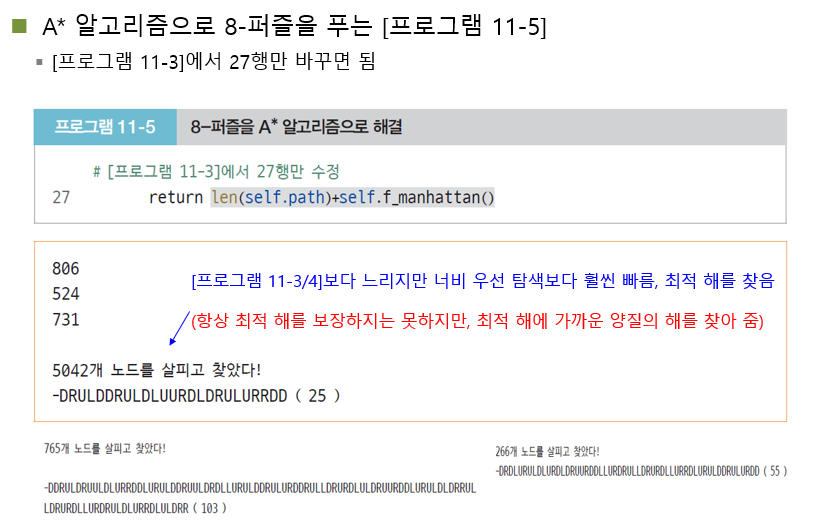

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 8-퍼즐(슬라이딩 퍼즐) 문제를 최적의 해(최소 이동 경로)로 푸는 A* 알고리즘의 예시임.
# 각 퍼즐 상태는 Node 클래스로 관리되며, Node는 퍼즐 상태(state), 이동 경로(path), f값(val)을 저장함.
# f값은 A* 공식 f(n) = g(n) + h(n)에 따라, g(n)은 지금까지의 경로 길이(len(self.path)), h(n)은 맨해튼 거리(self.f_manhattan())로 계산함.
# Move 함수는 현재 상태에서 빈 칸을 상하좌우로 움직여 생성 가능한 모든 자식 노드(후보 상태)를 반환함.
# PriorityQueue를 이용해 f값이 작은(즉, 더 유망한) 노드부터 탐색하고, 중복 상태 방문을 방지함.
# 목표 상태에 도달하면 전체 방문 노드 수, 이동 경로, 이동 횟수를 출력함.
# 본 코드는 인공지능 탐색 실습, 퍼즐 문제 풀이, 알고리즘 설계 교육에 최적화됨.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 퍼즐 초기 설정(시작/목표 상태, 보드 크기)
# 2단계: 상태+경로+평가값(f) 저장 Node 클래스 정의
# 3단계: 퍼즐 상태 출력 함수 정의
# 4단계: 자식 노드(후보) 생성 함수 정의
# 5단계: A* 탐색 메인 루프 및 해답 출력
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 퍼즐 초기 설정]
# ------------------------------------------------------------
from math import sqrt
# 보드의 한 변 길이(크기)를 계산하기 위해 math 모듈을 임포트함

from queue import PriorityQueue
# A* 탐색에 사용할 우선순위 큐(PriorityQueue) 자료구조를 임포트함

start = '806524731'
# 퍼즐의 시작 상태를 9자리 문자열로 지정함. 0은 빈 칸의 위치를 의미함

goal = '123456780'
# 퍼즐의 목표 상태(완성 상태)를 문자열로 정의함

n = int(sqrt(len(goal)))
# 목표 상태 문자열의 길이의 제곱근을 구하여 보드의 가로/세로 칸 수로 사용함

# ------------------------------------------------------------
# [2단계: 상태+경로+평가값(f) 저장 Node 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, path):
        self.state = state
        # 현재 퍼즐 상태(문자열)를 저장함
        self.path = path
        # 현재 상태에 도달하기까지의 이동 경로(문자열 누적)를 저장함
        self.val = self.f()
        # 이 노드의 f값(A* 평가값)을 계산하여 val에 저장함(우선순위 큐에서 사용함)

    def f_mismatch(self):
        # 불일치 개수 휴리스틱(참고용, 실제 사용하지 않음)
        return sum(self.state[i] != goal[i] for i in range(len(goal)))
        # 각 자리의 숫자가 목표 상태와 다르면 1씩 합산하여 반환함

    def f_manhattan(self):
        # 맨해튼 거리 휴리스틱 함수 정의임
        dist = 0
        # 총 거리를 누적할 변수 선언임
        for i in range(len(goal)):
            r, c = i // n, i % n
            # 목표 상태에서의 행, 열 좌표 계산임
            r1, c1 = self.state.index(goal[i]) // n, self.state.index(goal[i]) % n
            # 현재 상태에서 목표 숫자가 위치한 인덱스를 행, 열로 변환함
            dist += abs(r1 - r) + abs(c1 - c)
            # 행 차이, 열 차이의 합(맨해튼 거리)를 누적함
        return dist
        # 전체 맨해튼 거리 합을 반환함

    def f(self):
        # A*의 f(n) = g(n) + h(n) 계산 구간임
        return len(self.path) + self.f_manhattan()
        # g(n): 지금까지의 이동 경로 길이(실제 이동 횟수), h(n): 맨해튼 거리(남은 예상 거리)의 합을 반환함

    def __lt__(self, other):
        # PriorityQueue에서 Node 간 비교 연산 정의임
        return self.val < other.val
        # 평가값(f)이 작은 노드가 더 높은 우선순위를 가짐

# ------------------------------------------------------------
# [3단계: 퍼즐 상태 2차원 출력 함수 정의]
# ------------------------------------------------------------
def print_puzzle(state):
    # 퍼즐 상태 문자열을 2차원 배열 형태로 사람이 읽기 쉽게 출력하는 함수 정의임
    for i in range(n):
        print(state[n*i:n*(i+1)])
        # 퍼즐 상태 문자열에서 현재 행에 해당하는 부분만 잘라서 한 줄로 출력함

# ------------------------------------------------------------
# [4단계: 자식 노드(후보) 생성 함수 정의]
# ------------------------------------------------------------
def Move(node):
    # 입력 node에서 이동 가능한 모든 자식 노드(상태+경로)를 리스트로 반환하는 함수 정의임
    p = node.state
    # 현재 노드의 퍼즐 상태 문자열을 p에 저장함
    i = p.index('0')
    # 빈 칸(0)의 인덱스 위치를 구함. 이동 기준점이 됨
    child = []
    # 생성될 자식 노드를 저장할 리스트 선언임

    if not (i % n == 0):
        # 빈 칸이 좌측 끝이 아닐 때(왼쪽 이동 가능 시) 조건 판단임
        q = p[:i-1] + p[i] + p[i-1] + p[i+1:]
        # 왼쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'L'))
        # 새 상태 q와 이동 경로에 'L'을 추가한 Node 객체를 리스트에 추가함

    if not (i % n == n-1):
        # 빈 칸이 우측 끝이 아닐 때(오른쪽 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+1] + p[i] + p[i+2:]
        # 오른쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'R'))
        # 새 상태 q와 이동 경로에 'R'을 추가한 Node 객체를 리스트에 추가함

    if i >= n:
        # 빈 칸이 맨 위 행이 아닐 때(위로 이동 가능 시) 조건 판단임
        q = p[:i-n] + p[i] + p[i-n+1:i] + p[i-n] + p[i+1:]
        # 위쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'U'))
        # 새 상태 q와 이동 경로에 'U'를 추가한 Node 객체를 리스트에 추가함

    if i < n * n - n:
        # 빈 칸이 맨 아래 행이 아닐 때(아래로 이동 가능 시) 조건 판단임
        q = p[:i] + p[i+n] + p[i+1:i+n] + p[i] + p[i+n+1:]
        # 아래쪽 칸과 빈 칸(0)을 교환한 새로운 상태 문자열 q를 생성함
        child.append(Node(q, node.path + 'D'))
        # 새 상태 q와 이동 경로에 'D'를 추가한 Node 객체를 리스트에 추가함

    return child
    # 생성된 모든 자식 노드 리스트를 반환함

# ------------------------------------------------------------
# [5단계: A* 탐색 메인 루프 및 해답 출력]
# ------------------------------------------------------------
print_puzzle(start)
# 시작 퍼즐 상태를 2차원 형태로 출력하여 초기 상태를 시각적으로 확인함

Q = PriorityQueue()
# 우선순위 큐(PriorityQueue) 객체를 생성함

root = Node(start, '-')
# 시작 상태와 경로('-')를 가지는 Node 객체를 루트로 생성함

Q.put(root)
# 루트 노드를 큐에 삽입하여 탐색의 시작점으로 지정함

V = [root.state]
# 방문한 퍼즐 상태(중복 방지 목적)를 저장할 리스트를 생성함. 시작 상태를 포함함

while not Q.empty():
    # 큐가 빌 때까지(즉, 탐색할 노드가 남아있는 동안) 반복 수행함
    node = Q.get()
    # 큐에서 f값이 가장 낮은 Node 객체를 꺼내어 현재 탐색 대상으로 사용함

    if node.state == goal:
        # 현재 노드의 퍼즐 상태가 목표 상태와 일치하는지 확인함
        print(len(V), '개 노드를 살피고 찾았다!')
        # 목표 상태에 도달했으면 방문한 노드 개수와 함께 성공 메시지를 출력함
        break
        # 탐색 루프를 즉시 종료함

    else:
        # 목표 상태가 아니라면
        child = Move(node)
        # 현재 노드에서 이동 가능한 모든 자식 노드 리스트를 구함

        for j in range(len(child)):
            # 각 자식 노드를 순회하면서
            if child[j].state not in V:
                # 해당 자식 상태가 아직 방문한 적이 없는 경우에만 처리함(중복 탐색 방지 목적)
                Q.put(child[j])
                # 자식 노드를 우선순위 큐에 추가하여 다음 탐색 대상으로 등록함
                V.append(node.state)
                # 방문한 상태 리스트에도 추가하여 이후 중복 방문을 방지함

print(node.path, "(", len(node.path)-1, ")")
# 목표 상태에 도달한 마지막 노드의 이동 경로 문자열과 이동 횟수(문자 개수-1)를 함께 출력함


---

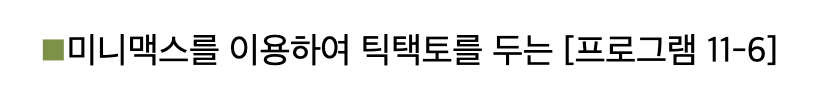

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 n x n 크기의 틱택토(Tic-Tac-Toe) 게임에서 미니맥스(minimax) 알고리즘을 사용해
# 컴퓨터(X)와 사람(O)가 번갈아 대국하는 자동 플레이 시스템임.
# 게임판 상태는 문자열로 표현하며, 각 함수는 보드 상태 업데이트, 승자 판정, 가능한 수 탐색,
# 미니맥스 재귀 탐색, 플레이어 전환 등 모든 게임 로직을 포함함.
# 컴퓨터는 항상 미니맥스 알고리즘으로 최적 수를 선택하고, 사람은 직접 입력으로 수를 두며,
# 게임 종료(승자, 무승부) 시 결과를 바로 출력함.
# 본 코드는 게임 구현, AI 탐색 원리, 재귀적 최적화 설계, 사용자 인터랙션 기초 실습 등에 모두 활용 가능함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 보드 크기 및 빈 보드 상태 초기화
# 2단계: 상태 업데이트 및 플레이어 전환 함수 정의
# 3단계: 보드 출력 및 빈 칸 탐색 함수 정의
# 4단계: 승자 결정 함수 정의
# 5단계: 미니맥스(minimax) 탐색 알고리즘 정의
# 6단계: 틱택토 메인 플레이 루프 함수 정의 및 실행
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 보드 크기 및 빈 보드 상태 초기화]
# ------------------------------------------------------------
n = 3
# 게임판의 크기를 n x n(3x3)으로 지정함

start = '-' * (n * n)
# n x n 크기만큼의 문자열로 빈 보드 상태(모든 칸 '-')를 생성함

# ------------------------------------------------------------
# [2단계: 상태 업데이트 및 플레이어 전환 함수 정의]
# ------------------------------------------------------------
def Move(state, pos, player):
    # 현재 state에서 pos 위치에 player 기호를 두는 새로운 상태를 반환하는 함수 정의임
    return state[:pos] + player + state[pos+1:]
    # pos 이전까지는 기존 상태 유지, pos에는 player를 넣고, 이후는 기존 상태를 붙여 새 문자열 생성함

def switch_player(player):
    # 현재 플레이어를 받아 반대 기호('O' <-> 'X')로 반환하는 함수 정의임
    return 'X' if player == 'O' else 'O'
    # O면 X, X면 O를 반환함

# ------------------------------------------------------------
# [3단계: 보드 출력 및 빈 칸 탐색 함수 정의]
# ------------------------------------------------------------
def print_board(state):
    # 보드 상태 문자열을 n x n 형태로 사람이 읽기 쉽게 출력하는 함수 정의임
    print('  0123456789012345'[:n+2])
    # 상단에 x축 인덱스(좌표)를 출력함
    for i in range(n):
        print(str(i%10) + ':' + state[n*i:n*(i+1)])
        # 각 행의 인덱스와 함께 현재 행 상태를 잘라서 출력함

def get_empty(state):
    # 현재 상태에서 빈 칸(둘 수 있는 칸)들의 인덱스 리스트를 반환하는 함수 정의임
    if decide_winner(state) in ['O', 'X', 'T']:
        # 이미 승부가 끝난 상태라면
        return []
        # 빈 칸 없음 반환(추가 수 불가)
    empty = []
    # 빈 칸 인덱스를 모을 리스트 생성
    for i in range(len(start)):
        if state[i] == '-':
            empty.append(i)
            # 해당 인덱스가 빈 칸이면 리스트에 추가함
    return empty
    # 모든 빈 칸의 인덱스 리스트 반환

# ------------------------------------------------------------
# [4단계: 승자 결정 함수 정의]
# ------------------------------------------------------------
def decide_winner(state):
    # 현재 상태에서 승자/무승부/진행중 여부를 판정하는 함수 정의임
    for (a, b, c) in [(0,1,2), (3,4,5), (6,7,8), (0,3,6), (1,4,7), (2,5,8), (0,4,8), (2,4,6)]:
        # 가로, 세로, 대각선 모든 라인 조합을 순회함
        if state[a] == state[b] == state[c]:
            # 세 칸이 모두 같다면
            if state[a] == 'O': return 'O'
            # O로 모두 같으면 O 승리
            elif state[a] == 'X': return 'X'
            # X로 모두 같으면 X 승리
    if [i for i in range(n*n) if state[i] == '-'] == []:
        return 'T'
        # 빈 칸이 더 이상 없으면 무승부(Tie) 반환
    return 'N'
    # 위 조건에 모두 해당하지 않으면 아직 승부 미확정(N) 반환

# ------------------------------------------------------------
# [5단계: 미니맥스(minimax) 탐색 알고리즘 정의]
# ------------------------------------------------------------
def minimax(state, player, depth):
    # 미니맥스 알고리즘(최적 수 탐색, 컴퓨터 vs 사람)을 재귀적으로 구현한 함수 정의임
    winner = decide_winner(state)
    # 현재 상태의 승자 판정값을 winner에 저장함
    if winner == 'X':
        return 1, None
        # 컴퓨터 승리 시 1점 반환, 다음 위치 의미 없음
    elif winner == 'O':
        return -1, None
        # 사람 승리 시 -1점 반환, 다음 위치 의미 없음
    elif winner == 'T':
        return 0, None
        # 무승부 시 0점 반환, 다음 위치 의미 없음

    e = get_empty(state)
    # 현재 상태에서 둘 수 있는 빈 칸의 인덱스를 모두 구함
    if depth % 2 == 0:
        # 짝수 단계(컴퓨터 차례)면 최대값(최적) 선택
        vmax, bestpos = -100, None
        # 최대값, 최적 위치 초기화
        for pos in e:
            v, _ = minimax(Move(state, pos, player), switch_player(player), depth+1)
            # 가능한 모든 다음 수에 대해 재귀적으로 minimax를 호출해 값을 계산함
            if v > vmax:
                vmax, bestpos = v, pos
                # 최대값과 최적 위치를 갱신함
        return vmax, bestpos
        # 이 단계에서의 최대값과 최적 수 위치 반환
    else:
        # 홀수 단계(사람 차례)면 최소값(상대 최적) 선택
        vmin, bestpos = 100, None
        # 최소값, 최적 위치 초기화
        for pos in e:
            v, _ = minimax(Move(state, pos, player), switch_player(player), depth+1)
            # 가능한 모든 다음 수에 대해 재귀적으로 minimax를 호출해 값을 계산함
            if v < vmin:
                vmin, bestpos = v, pos
                # 최소값과 최적 위치를 갱신함
        return vmin, bestpos
        # 이 단계에서의 최소값과 최적 수 위치 반환

# ------------------------------------------------------------
# [6단계: 틱택토 메인 플레이 루프 함수 정의 및 실행]
# ------------------------------------------------------------
def tictactoe_play(first_mover):
    # 틱택토 게임을 실제로 진행하는 메인 함수 정의임
    state = start
    # 현재 상태를 빈 보드로 초기화함
    player = first_mover
    # 시작 플레이어('O' 또는 'X')를 설정함
    print_board(state)
    # 초기 보드를 화면에 출력함
    while True:
        if player == 'X':
            print("컴퓨터 차례입니다.")
            # 컴퓨터(X) 차례 안내 메시지 출력
            val, pos = minimax(state, player, 0)
            # minimax 알고리즘으로 최적 수(위치) 결정
        elif player == 'O':
            x, y = input("사람 차례입니다. (x와 y를 공백 구분하여 입력하세요.)").split()
            # 사용자로부터 x, y 좌표 입력받음
            pos = int(y) * n + int(x)
            # (x, y) 좌표를 1차원 인덱스(pos)로 변환함
            if state[pos] != '-':
                print("둘 수 없는 곳입니다.")
                # 이미 돌이 놓인 곳이면 경고 후 다시 입력받음
                continue
        state = Move(state, pos, player)
        # 선택된 위치에 현재 플레이어의 돌을 두고, 상태를 업데이트함
        print_board(state)
        # 변경된 보드 상태를 출력함
        winner = decide_winner(state)
        # 승자(혹은 무승부) 판정
        if winner in ['O', 'X', 'T']:
            if winner == 'T': print('비겼습니다.')
            # 무승부일 경우 결과 출력
            else: print(winner, '가 이겼습니다.')
            # 승자 출력
            break
            # 게임 종료
        player = switch_player(player)
        # 플레이어를 교체함

tictactoe_play('O')
# 틱택토 게임을 실제로 실행하며, 사람(O)이 선공으로 시작함


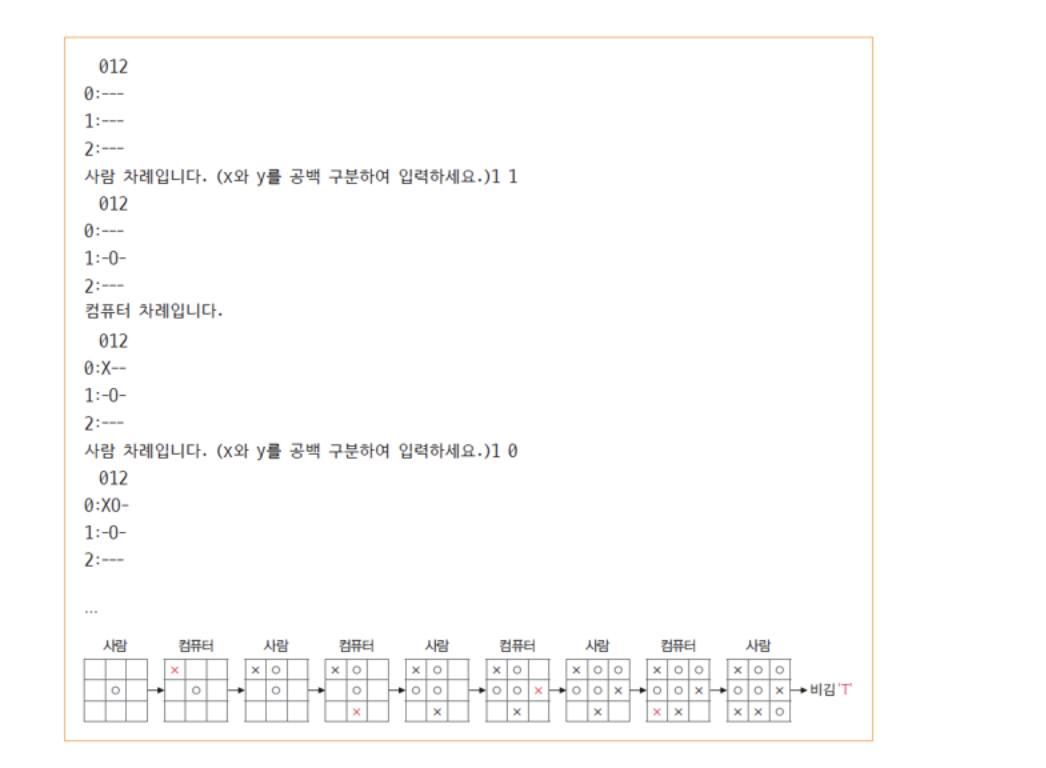

---

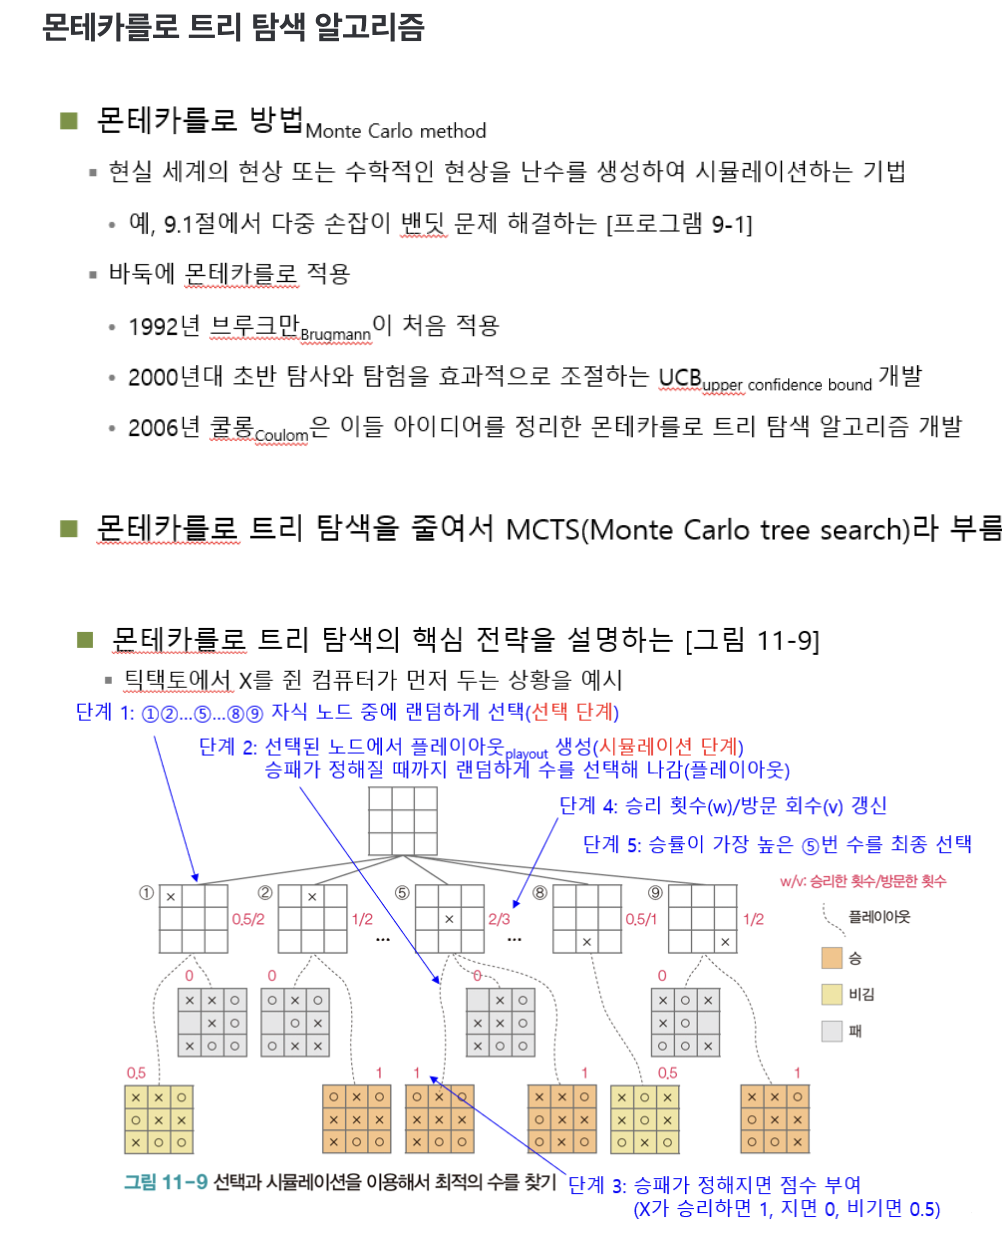

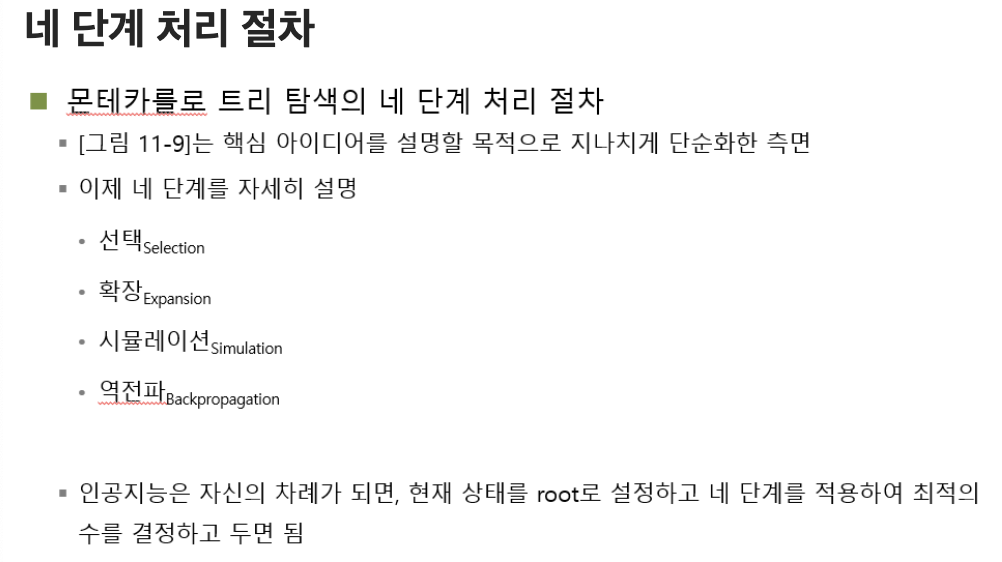

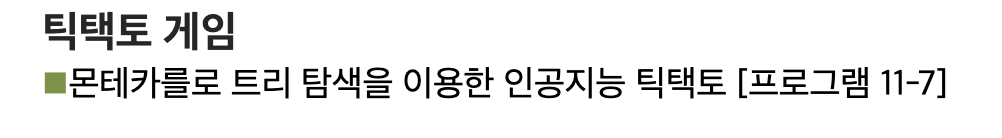

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 3x3 틱택토(Tic-Tac-Toe) 게임에서 컴퓨터(X)가 MCTS(Monte Carlo Tree Search) 알고리즘으로  
# 최적의 수를 선택하고, 사람이 O로 직접 대국하는 인터랙티브 AI 플레이 코드임.
# MCTS는 시뮬레이션 기반 트리 탐색으로 각 노드의 UCT(Upper Confidence Bound for Trees) 값을 사용해  
# 확장·선택·시뮬레이션·백트래킹의 4단계를 반복하며, 1만번의 반복을 통해 가장 승률이 높은 수를 선택함.
# Node 클래스는 게임 상태, 플레이어, 수, 부모·자식 관계, 방문·승리 횟수 등 MCTS의 모든 정보를 관리함.
# 게임의 진행은 보드 출력, 입력 처리, 게임 종료 판정 등 실전적 구조로 이루어짐.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 게임 보드 크기 및 빈 보드 상태 초기화
# 2단계: MCTS 탐색 노드(Node) 클래스 정의
# 3단계: 상태 업데이트, 플레이어 전환, 보드 출력, 빈 칸 탐색, 승자 판정 함수 정의
# 4단계: MCTS(Monte Carlo Tree Search) 구현
# 5단계: 틱택토 메인 플레이 루프 함수 정의 및 실행
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 게임 보드 크기 및 빈 보드 상태 초기화]
# ------------------------------------------------------------
n = 3
# 보드의 크기를 n x n(3x3)으로 지정함

start = '-' * (n * n)
# n x n 크기의 문자열로 빈 보드 상태를 생성함. 각 칸은 '-'로 초기화함

# ------------------------------------------------------------
# [2단계: MCTS 탐색 노드(Node) 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, player=None, pos=None, parent=None):
        self.state = state
        # 현재 게임 상태(문자열)를 저장함
        self.player = player
        # 이 노드에 착수한 플레이어(O 또는 X)를 저장함
        self.pos = pos
        # 이 노드에 도달하기 위해 놓은 위치 인덱스를 저장함
        self.parent = parent
        # 부모 노드를 저장함(트리 구조 추적용)
        self.nwin = 0
        # 해당 노드에서의 승리 횟수 누적값을 저장함
        self.nvisit = 0
        # 해당 노드의 방문(시뮬레이션) 횟수 누적값을 저장함
        self.untried = get_empty(state)
        # 이 노드에서 아직 확장되지 않은 수(빈 칸 인덱스) 리스트를 저장함
        self.children = []
        # 현재 노드의 자식 노드 리스트를 저장함

    def UCTselect(self):
        # 자식 노드들 중 UCT(Upper Confidence Bound for Trees) 값을 기준으로  
        # 가장 탐색 가치가 높은 노드를 선택하는 함수임
        s = sorted(
            self.children,
            key=lambda c: c.nwin / c.nvisit + sqrt(log(self.nvisit) / c.nvisit)
        )
        # 각 자식 노드에 대해 승률(nwin/nvisit)과 탐사 보상(sqrt(log(부모방문)/자식방문))을 합산해 정렬함
        return s[-1]
        # UCT 값이 가장 높은(가장 탐색 가치가 큰) 노드를 반환함

    def makeChild(self, state, pos, player):
        # 현재 노드에서 실제 착수(pos)를 실행해 자식 노드(새 상태, 새 플레이어)를 생성하는 함수임
        node = Node(state, player, pos, parent=self)
        # 새 노드 객체를 생성함(부모를 자기 자신으로 지정)
        self.untried.remove(pos)
        # 아직 확장하지 않은 수 리스트에서 해당 위치를 제거함
        self.children.append(node)
        # 생성된 자식 노드를 리스트에 추가함
        return node
        # 새로 생성된 자식 노드를 반환함

    def update(self, winner):
        # 해당 노드의 방문 횟수, 승리 횟수를 백트래킹 시 업데이트하는 함수임
        self.nvisit += 1
        # 방문 횟수 1 증가
        if winner == 'T':
            self.nwin += 0.5
            # 무승부 시 0.5점만 추가
        elif winner == self.player:
            self.nwin += 1
            # 자신이 이긴 경우 1점 추가

    def __repr__(self):
        # 객체를 문자열로 출력할 때 게임 상태와 승/방문 횟수 비율을 함께 보여주는 함수임
        return str(self.state) + " " + str(self.nwin) + "/" + str(self.nvisit)

# ------------------------------------------------------------
# [3단계: 상태 업데이트, 플레이어 전환, 보드 출력, 빈 칸 탐색, 승자 판정 함수 정의]
# ------------------------------------------------------------
def Move(state, pos, player):
    # state의 pos 위치에 player의 돌을 두고, 새 상태 문자열을 반환하는 함수임
    return state[:pos] + player + state[pos+1:]
    # pos 이전까지 기존 상태, pos에 player 추가, 이후 기존 상태 연결로 새 문자열 생성

def switch_player(player):
    # 현재 플레이어가 O면 X, X면 O로 바꿔주는 함수임
    return 'X' if player == 'O' else 'O'
    # 삼항 연산자로 반대 기호 반환

def print_board(state):
    # 현재 보드를 사람이 보기 좋게 n x n 형태로 출력하는 함수임
    print('  0123456789012345'[:n+2])
    # x축(열) 인덱스 표시
    for i in range(n):
        print(str(i % 10) + ':' + state[n*i:n*(i+1)])
        # 각 행의 인덱스와 상태(문자열 슬라이스)를 함께 출력

def get_empty(state):
    # 승자가 이미 정해졌으면 빈 칸 없음([]) 반환, 아니면 빈 칸 위치 인덱스 리스트 반환
    if decide_winner(state) in ['O', 'X', 'T']:
        return []
    empty = []
    # 빈 칸 위치를 저장할 리스트 생성
    for i in range(len(start)):
        if state[i] == '-':
            empty.append(i)
    return empty
    # 모든 빈 칸 위치 인덱스 반환

def decide_winner(state):
    # 현재 상태에서 승자/무승부/진행중(N) 판정 함수임
    for (a, b, c) in [
        (0,1,2),(3,4,5),(6,7,8),
        (0,3,6),(1,4,7),(2,5,8),
        (0,4,8),(2,4,6)
    ]:
        if state[a] == state[b] == state[c]:
            if state[a] == 'O': return 'O'
            elif state[a] == 'X': return 'X'
    if [i for i in range(n*n) if state[i] == '-'] == []: return 'T'
    # 빈 칸이 없으면 무승부('T') 반환
    return 'N'
    # 승자 없고 빈 칸 있으면 진행 중('N') 반환

# ------------------------------------------------------------
# [4단계: MCTS(Monte Carlo Tree Search) 구현]
# ------------------------------------------------------------
def mcts(state, player):
    # 주어진 상태(state)에서 player가 둘 때 MCTS로 최적 수를 반환하는 함수임
    root = Node(state)
    # 트리의 루트 노드를 생성함(현 상태, 초기화)

    for i in range(10000):
        # 총 10000번(시뮬레이션) 반복으로 트리 확장, 평가를 수행함
        node = root
        state = node.state
        roll_player = player
        while node.untried == [] and node.children != []:
            # 아직 확장 안한 수가 없고, 자식이 있으면
            node = node.UCTselect()
            # UCT(승률+탐사보상) 기준으로 자식 노드를 선택함
            state = Move(state, node.pos, roll_player)
            # 해당 수를 두어 상태를 갱신함
            roll_player = switch_player(roll_player)
            # 플레이어를 전환함

        if node.untried != []:
            # 아직 확장하지 않은 수가 있으면
            pos = random.choice(node.untried)
            # 남은 후보 중 임의의 수를 하나 고름
            state = Move(state, pos, roll_player)
            # 선택된 위치에 착수한 새 상태로 갱신함
            node = node.makeChild(state, pos, roll_player)
            # 해당 수로 자식 노드를 만들어 트리에 추가하고, 현재 노드를 그 자식으로 변경함
            roll_player = switch_player(roll_player)
            # 플레이어를 전환함

        while True:
            # 시뮬레이션(랜덤 완전 플레이) 반복
            e = get_empty(state)
            # 남은 빈 칸 위치 리스트를 구함
            if e == []: break
            # 더 둘 수 없으면 시뮬레이션 종료
            state = Move(state, random.choice(e), roll_player)
            # 랜덤 수를 선택해 착수함
            roll_player = switch_player(roll_player)
            # 플레이어를 전환함

        winner = decide_winner(state)
        # 시뮬레이션 종료 후 최종 승자 판정
        while node != None:
            node.update(winner)
            # 백트래킹하며 각 노드의 방문/승리 횟수 갱신
            node = node.parent
            # 부모 노드로 거슬러 올라감

    # 시뮬레이션 종료 후, 승률이 가장 높은 자식의 pos(착수 위치) 반환
    return sorted(root.children, key=lambda c: c.nwin / c.nvisit)[-1].pos

# ------------------------------------------------------------
# [5단계: 틱택토 메인 플레이 루프 함수 정의 및 실행]
# ------------------------------------------------------------
def tictactoe_play(first_mover):
    state = start
    # 초기 보드를 빈 상태로 설정
    player = first_mover
    # 첫 플레이어를 인자로 받음
    print_board(state)
    # 보드 출력
    while True:
        if player == 'X':
            print("컴퓨터 차례입니다.")
            # 컴퓨터(X) 차례
            pos = mcts(state, player)
            # MCTS로 최적 수를 결정
        elif player == 'O':
            x, y = input("사람 차례입니다. (x와 y를 공백 구분하여 입력하세요.)").split()
            # 사용자로부터 x, y 입력받음
            pos = int(y) * n + int(x)
            # 2차원 좌표를 1차원 인덱스로 변환
            if state[pos] != '-':
                print("둘 수 없는 곳입니다.")
                # 이미 돌이 놓인 곳이면 안내 후 다시 입력받음
                continue
        state = Move(state, pos, player)
        # 결정된 위치에 착수하고 상태를 갱신
        print_board(state)
        # 보드 출력
        winner = decide_winner(state)
        # 승자 판정
        if winner in ['O', 'X', 'T']:
            if winner == 'T':
                print('비겼습니다.')
                # 무승부 안내
            else:
                print(winner, '가 이겼습니다.')
                # 승자 안내
            break
            # 게임 종료
        player = switch_player(player)
        # 플레이어 전환

# 틱택토를 시작하는 main
tictactoe_play('O')
# 사람(O) 선공으로 틱택토 게임을 시작함


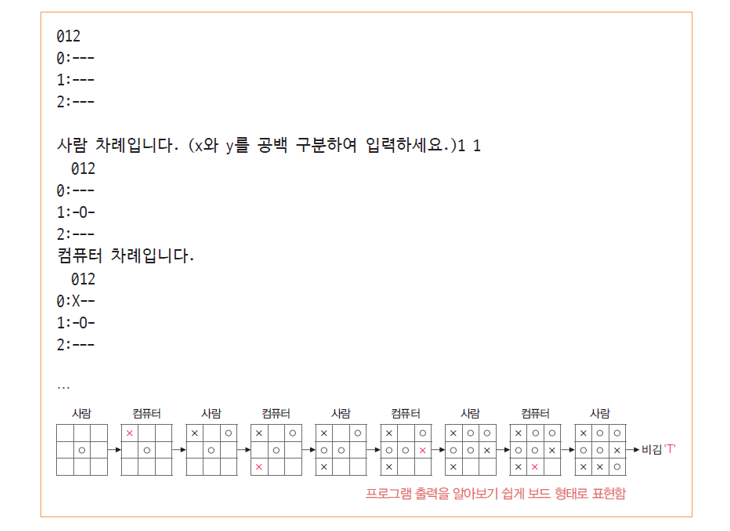

---

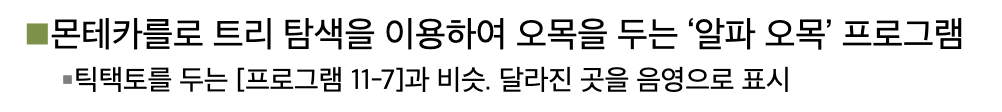

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 10x10 오목(연속 k=5, 즉 5목) 게임에서 몬테카를로 트리 탐색(MCTS, Monte Carlo Tree Search) AI가
# 컴퓨터(X) 역할로 최적 수를 두고, 사람이 O로 직접 대국할 수 있는 자동 대국 시스템임.
# 각 상태는 문자열로 표현하며, Node 클래스에서 트리 구조, 승/방문 횟수, 미확장 수 등을 관리함.
# 승자 판정은 5목 연속 여부(가로, 세로, 대각선)로 하며, get_empty는 인접 칸만 허용해 성능을 높임.
# 컴퓨터는 1만번 MCTS로 수를 선택, 중앙 근처 우선, 진행 시간 출력까지 모두 포함함.
# 본 코드는 AI 게임 엔진, MCTS 실습, 상태 관리, 오목 로직 이해 등 고급 인공지능 응용 예제임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 오목 보드/규칙 파라미터 및 빈 상태 초기화
# 2단계: MCTS 트리 노드(Node) 클래스 정의
# 3단계: 랜덤 중앙 시작, 상태 업데이트, 플레이어 전환, 보드 출력, 빈 칸/승자 판정 함수 정의
# 4단계: 몬테카를로 트리 탐색(MCTS) 구현
# 5단계: 오목 메인 플레이 루프 함수 정의 및 실행
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 오목 보드/규칙 파라미터 및 빈 상태 초기화]
# ------------------------------------------------------------
n = 10
# 오목 보드의 한 변 크기를 10으로 지정함

k = 5
# 승리 조건: 같은 돌을 연속으로 k(5)개 두면 승리함

start = '-' * (n * n)
# n x n 크기의 문자열로 빈 보드 상태를 생성함. 각 칸은 '-'로 초기화함

# ------------------------------------------------------------
# [2단계: MCTS 트리 노드(Node) 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, player=None, pos=None, parent=None):
        self.state = state
        # 현재 오목판 상태(문자열)를 저장함
        self.player = player
        # 착수한 플레이어(O 또는 X)를 저장함
        self.pos = pos
        # 방금 착수한 위치 인덱스를 저장함
        self.parent = parent
        # 부모 노드(트리 백트래킹용)를 저장함
        self.nwin = 0
        # 이 노드에서의 누적 승리 횟수를 저장함
        self.nvisit = 0
        # 이 노드의 시뮬레이션(방문) 횟수 누적값을 저장함
        self.untried = get_empty(state)
        # 이 상태에서 아직 확장되지 않은 후보 수(인접 칸 리스트) 저장함
        self.children = []
        # 현재 노드의 자식 노드(트리 구조) 리스트를 저장함

    def UCTselect(self):
        # 자식 노드들 중 UCT(Upper Confidence Bound for Trees) 기준  
        # 가장 탐색 가치가 높은 노드를 반환하는 함수임
        s = sorted(
            self.children,
            key=lambda c: c.nwin / c.nvisit + sqrt(log(self.nvisit) / c.nvisit)
        )
        # 각 자식 노드의 (승률 + 탐사보상) 기준으로 정렬함
        return s[-1]
        # UCT 값이 가장 높은 노드를 반환함

    def makeChild(self, state, pos, player):
        # 현재 노드에서 착수(pos)를 실행해 자식 노드를 생성하는 함수임
        node = Node(state, player, pos, parent=self)
        # 새 노드 객체 생성(부모는 자기 자신)
        self.untried.remove(pos)
        # 미확장 수 리스트에서 해당 위치를 제거함
        self.children.append(node)
        # 새로 만든 자식 노드를 리스트에 추가함
        return node
        # 생성된 자식 노드 반환

    def update(self, winner):
        # 백트래킹 과정에서 해당 노드의 방문/승리 횟수 누적값을 업데이트하는 함수임
        self.nvisit += 1
        # 방문 횟수 1 증가
        if winner == 'T':
            self.nwin += 0.5
            # 무승부(T)일 경우 0.5점만 추가
        elif winner == self.player:
            self.nwin += 1
            # 자신이 이긴 경우 1점 추가

    def __repr__(self):
        # 노드 객체의 문자열 표현: 상태, 승/방문 횟수 비율을 함께 출력함
        return str(self.state) + " " + str(self.nwin) + "/" + str(self.nvisit)

# ------------------------------------------------------------
# [3단계: 랜덤 중앙 시작, 상태 업데이트, 플레이어 전환, 보드 출력, 빈 칸/승자 판정 함수 정의]
# ------------------------------------------------------------
def randomAroundCenter(n):
    # 중앙 인근의 인덱스들 중 무작위로 하나를 반환하는 함수임(초기 수 제한용)
    c = n * (n // 2) + n // 2
    # 중앙 칸 인덱스 계산
    return random.choice([c, c-1, c+1, c-n, c+n])
    # 중앙 또는 바로 인접 칸 중 랜덤 선택 반환

def Move(state, pos, player):
    # 현재 state에서 pos 위치에 player 돌을 두고 새 상태 반환
    return state[:pos] + player + state[pos+1:]

def switch_player(player):
    # 현재 플레이어가 O면 X, X면 O로 바꿔주는 함수임
    return 'X' if player == 'O' else 'O'

def print_board(state):
    # 보드 상태를 n x n 형태로 사람이 보기 쉽게 출력하는 함수임
    print('  0123456789012345'[:n+2])
    # x축(열) 인덱스 출력
    for i in range(n):
        print(str(i%10) + ':' + state[n*i:n*(i+1)])
        # 각 행의 인덱스와 해당 행 상태(문자열 슬라이스)를 출력

def get_empty(state):
    # 착수 후보를 기존 수의 인접 칸으로만 제한해 반환하는 함수임
    if decide_winner(state) in ['O','X','T']:
        return []
        # 이미 승부가 끝난 상태면 빈 칸 없음 반환
    empty = []
    for i in range(len(start)):
        if state[i] != '-': continue
        # 빈 칸이 아니면 넘어감
        r, c = i // n, i % n
        # 2차원 좌표로 변환
        for (y, x) in [(r-1,c-1),(r-1,c),(r-1,c+1),(r,c-1),(r,c+1),(r+1,c-1),(r+1,c),(r+1,c+1)]:
            if y >= 0 and y <= n-1 and x >= 0 and x <= n-1 and state[y*n+x] != '-' and y*n+x not in empty:
                empty.append(i)
                break
    return empty
    # 모든 인접 착수 가능 칸 인덱스 반환

def decide_winner(state):
    # 오목의 승자(연속 k개)를 판정하는 함수임
    nvoid = 0
    for i in range(n*n):
        s = state[i]
        if s == '-': nvoid += 1; continue
        r, c = i // n, i % n
        # 각 칸에서 가로, 세로, 대각선 4방향에 대해 k개 연속 여부를 모두 확인함
        # 가로
        c1 = c-1; c2 = c+1
        while c1 >= 0 and state[r*n+c1] == s: c1 -= 1
        while c2 <= n-1 and state[r*n+c2] == s: c2 += 1
        if c2-c1-1 == k: return s
        # 세로
        r1 = r-1; r2 = r+1
        while r1 >= 0 and state[r1*n+c] == s: r1 -= 1
        while r2 <= n-1 and state[r2*n+c] == s: r2 += 1
        if r2-r1-1 == k: return s
        # 대각선 /
        r1 = r-1; c1 = c-1; r2 = r+1; c2 = c+1
        while r1 >= 0 and c1 >= 0 and state[r1*n+c1] == s: r1, c1 = r1-1, c1-1
        while r2 <= n-1 and c2 <= n-1 and state[r2*n+c2] == s: r2, c2 = r2+1, c2+1
        if r2-r1-1 == k: return s
        # 대각선 \
        r1 = r-1; c1 = c+1; r2 = r+1; c2 = c-1
        while r1 >= 0 and c1 <= n-1 and state[r1*n+c1] == s: r1, c1 = r1-1, c1+1
        while r2 <= n-1 and c2 >= 0 and state[r2*n+c2] == s: r2, c2 = r2+1, c2-1
        if r2-r1-1 == k: return s
    if nvoid == 0: return 'T'
    # 모든 칸이 차고 승자 없으면 무승부('T') 반환
    return 'N'
    # 아직 승자 없음(진행 중) 반환

# ------------------------------------------------------------
# [4단계: 몬테카를로 트리 탐색(MCTS) 구현]
# ------------------------------------------------------------
def mcts(state, player):
    root = Node(state)
    # 트리의 루트 노드를 현 상태로 생성함
    for i in range(10000):
        node = root
        state = node.state
        roll_player = player
        while node.untried == [] and node.children != []:
            node = node.UCTselect()
            state = Move(state, node.pos, roll_player)
            roll_player = switch_player(roll_player)
        if node.untried != []:
            pos = random.choice(node.untried)
            state = Move(state, pos, roll_player)
            node = node.makeChild(state, pos, roll_player)
            roll_player = switch_player(roll_player)
        while True:
            e = get_empty(state)
            if e == []: break
            state = Move(state, random.choice(e), roll_player)
            roll_player = switch_player(roll_player)
        winner = decide_winner(state)
        while node != None:
            node.update(winner)
            node = node.parent
    return sorted(root.children, key=lambda c: c.nwin / c.nvisit)[-1].pos
    # 시뮬레이션 후 승률이 가장 높은 자식 노드의 착수 위치 반환

# ------------------------------------------------------------
# [5단계: 오목 메인 플레이 루프 함수 정의 및 실행]
# ------------------------------------------------------------
def omok_play(first_mover):
    state = start
    player = first_mover
    print_board(state)
    while True:
        t1 = time.time()
        if player == 'X':
            if state == start:
                pos = randomAroundCenter(n)
                # 게임 첫 수는 중앙 또는 인접 칸에서 무작위로 선택함
            else:
                pos = mcts(state, player)
                # 그 외에는 MCTS로 최적 수 선택
        elif player == 'O':
            x, y = input("사람 차례입니다. (x와 y를 공백 구분하여 입력하세요.)").split()
            pos = int(y) * n + int(x)
            if state[pos] != '-':
                print("둘 수 없는 곳입니다.")
                continue
        state = Move(state, pos, player)
        print_board(state)
        winner = decide_winner(state)
        if winner in ['O', 'X', 'T']:
            if winner == 'T':
                print('비겼습니다.')
            else:
                print(winner, '가 이겼습니다.')
            break
        print(player, '가', round(time.time() - t1, 3), '초를 썼습니다.')
        player = switch_player(player)

# 오목 게임을 시작하는 main
omok_play('O')
# 사람(O) 선공으로 오목을 시작함

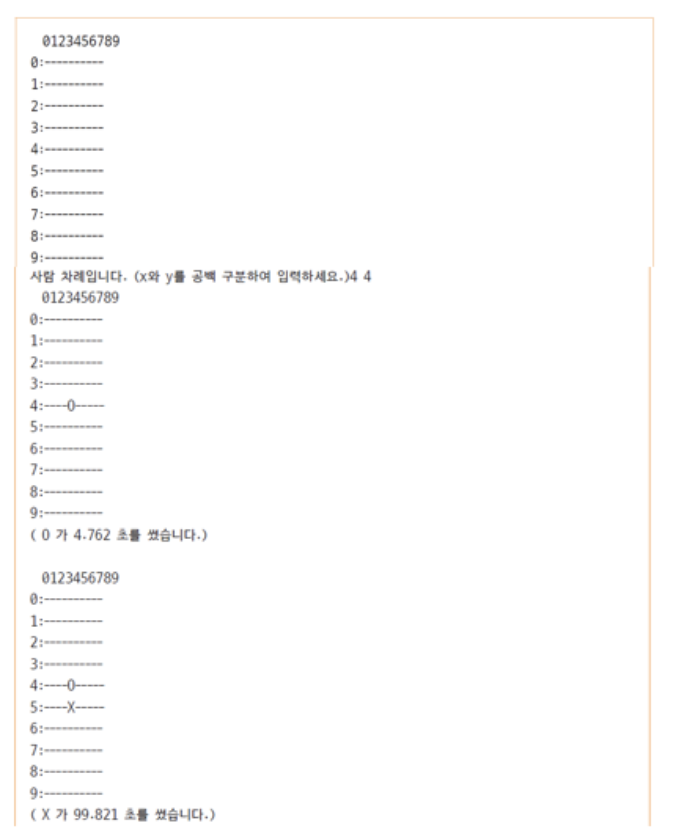
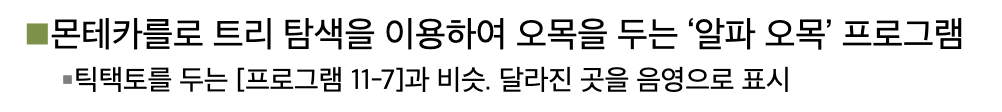

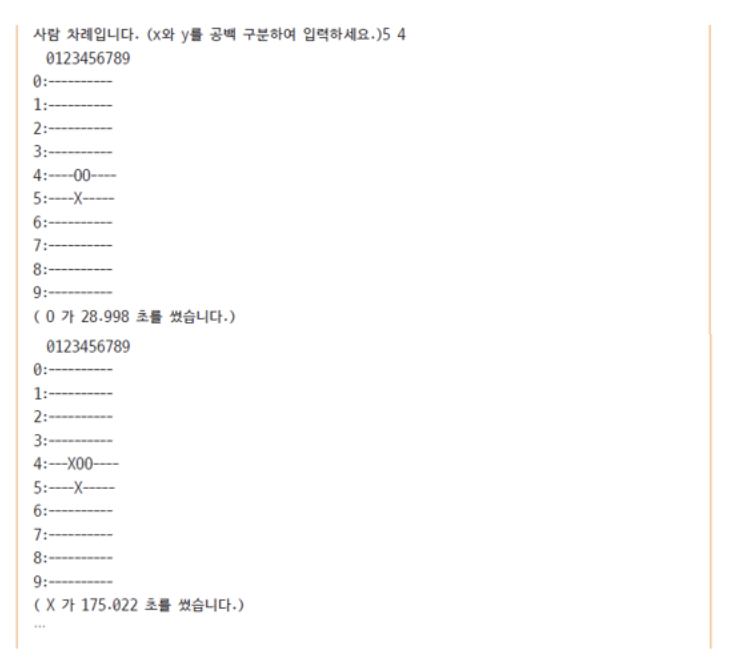

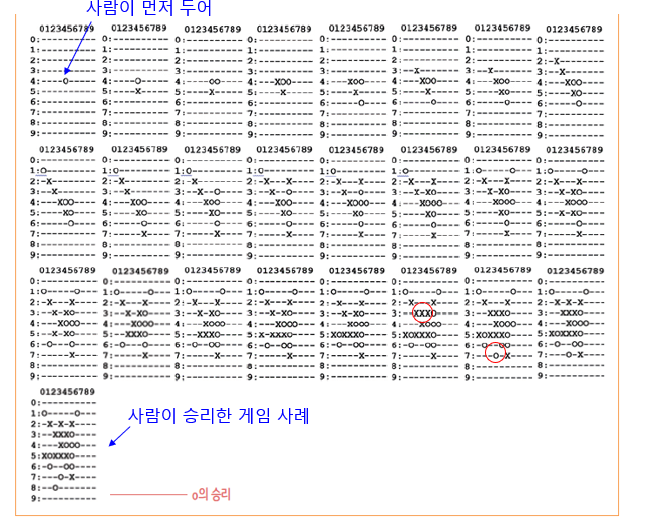

---

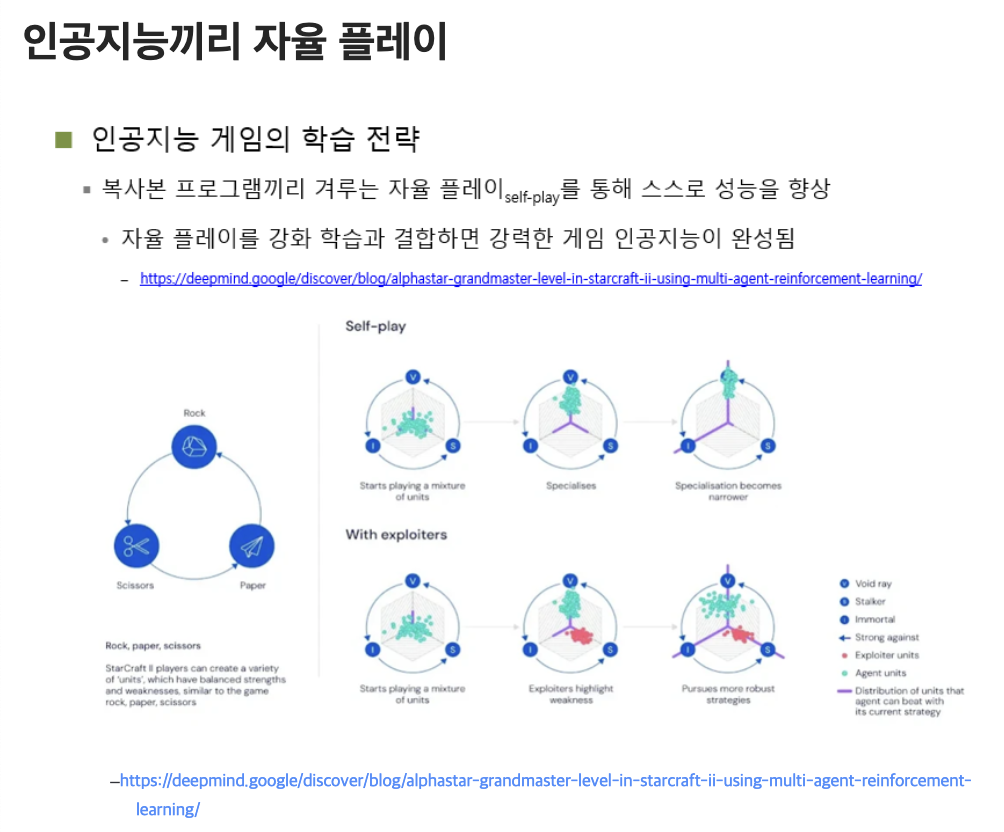

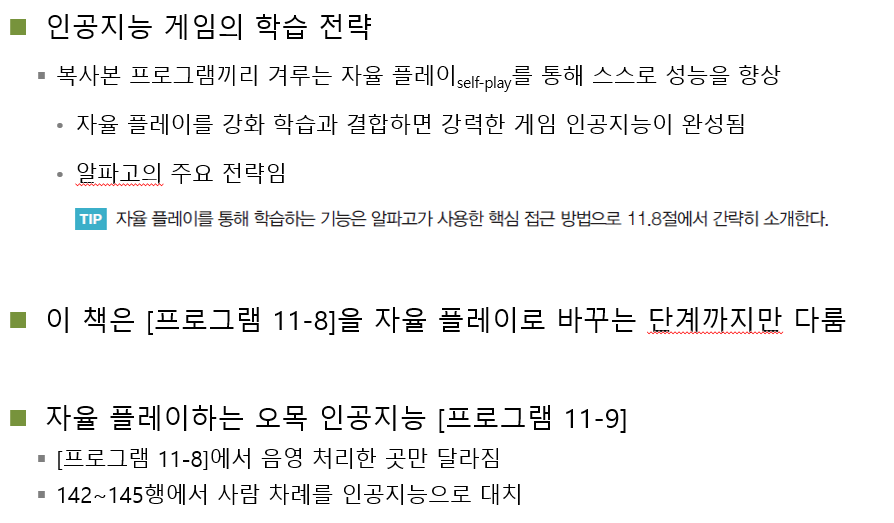

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 10x10 오목(연속 k=5) 게임에서 컴퓨터(X)와 컴퓨터(O)가 모두 몬테카를로 트리 탐색(MCTS) 알고리즘을 사용해  
# 스스로 번갈아 두는 완전 자동 셀프플레이 시뮬레이터임.
# 각 상태는 문자열로 표현하며, Node 클래스가 트리, 방문/승리 통계, 확장 후보 관리까지 모두 수행함.
# 승자 판정은 연속 5개(가로, 세로, 대각선)로 하며, 착수 후보는 기존 돌 인접 칸으로만 제한해 대규모 보드 최적화함.
# 각 수 마다 소요시간 출력, 게임 종료 시 결과까지 모두 자동 출력함.
# 오목 AI, MCTS, 상태 관리, 대국 기록, 실전 셀프플레이 등 고급 인공지능/게임 엔진 실습에 적합함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 오목 보드, 규칙, 빈 상태 초기화
# 2단계: MCTS 트리 노드(Node) 클래스 정의
# 3단계: 랜덤 중앙 착수, 상태 업데이트, 플레이어 전환, 보드 출력, 착수 후보/승자 판정 함수 정의
# 4단계: MCTS(Monte Carlo Tree Search) 구현
# 5단계: 오목 셀프플레이(자동대전) 루프 함수 정의 및 실행
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계: 오목 보드, 규칙, 빈 상태 초기화]
# ------------------------------------------------------------
n = 10
# 보드 한 변 크기(10x10)로 지정함

k = 5
# 승리 조건(같은 돌 연속 5개)을 저장함

start = '-' * (n * n)
# 빈 오목판 상태(문자열, 모두 '-')를 생성함

# ------------------------------------------------------------
# [2단계: MCTS 트리 노드(Node) 클래스 정의]
# ------------------------------------------------------------
class Node():
    def __init__(self, state, player=None, pos=None, parent=None):
        self.state = state
        # 현재 오목판 상태(문자열)를 저장함
        self.player = player
        # 착수한 플레이어(O 또는 X)를 저장함
        self.pos = pos
        # 방금 착수한 위치 인덱스를 저장함
        self.parent = parent
        # 부모 노드를 저장함
        self.nwin = 0
        # 누적 승리 횟수를 저장함
        self.nvisit = 0
        # 누적 방문(시뮬레이션) 횟수를 저장함
        self.untried = get_empty(state)
        # 확장되지 않은(착수 후보) 인접 칸 인덱스 리스트를 저장함
        self.children = []
        # 트리의 자식 노드 리스트를 저장함

    def UCTselect(self):
        # UCT(Upper Confidence Bound for Trees) 기준으로 자식 노드 선택 함수임
        s = sorted(
            self.children,
            key=lambda c: c.nwin / c.nvisit + sqrt(log(self.nvisit) / c.nvisit)
        )
        # 승률(nwin/nvisit) + 탐사보상(sqrt(log(parent.visit)/visit))로 정렬
        return s[-1]
        # UCT 값이 가장 높은 노드를 반환함

    def makeChild(self, state, pos, player):
        # 새로운 자식 노드 생성 및 트리 확장 함수임
        node = Node(state, player, pos, parent=self)
        # 새 노드를 생성함(부모: 자기 자신)
        self.untried.remove(pos)
        # 미확장 후보에서 해당 위치 제거
        self.children.append(node)
        # 자식 노드 리스트에 추가
        return node
        # 새 자식 노드 반환

    def update(self, winner):
        # 백트래킹 단계에서 방문/승리 횟수 누적 함수임
        self.nvisit += 1
        # 방문 횟수 증가
        if winner == 'T':
            self.nwin += 0.5
            # 무승부(T)시 0.5점만 추가
        elif winner == self.player:
            self.nwin += 1
            # 자신이 이긴 경우 1점 추가

    def __repr__(self):
        # 상태와 승률/방문 비율을 문자열로 출력하는 함수임
        return str(self.state) + " " + str(self.nwin) + "/" + str(self.nvisit)

# ------------------------------------------------------------
# [3단계: 랜덤 중앙 착수, 상태 업데이트, 플레이어 전환, 보드 출력, 착수 후보/승자 판정 함수 정의]
# ------------------------------------------------------------
def randomAroundCenter(n):
    # 중앙 및 인접 칸 중 무작위로 하나 반환하는 함수임
    c = n * (n // 2) + n // 2
    # 중앙 칸 인덱스 계산
    return random.choice([c, c-1, c+1, c-n, c+n])
    # 중앙 및 네 방향 인접 칸 무작위 반환

def Move(state, pos, player):
    # 현재 상태에서 pos 위치에 player 돌을 두고 새 상태 반환
    return state[:pos] + player + state[pos+1:]

def switch_player(player):
    # 현재 플레이어가 O면 X, X면 O로 바꿔주는 함수임
    return 'X' if player == 'O' else 'O'

def print_board(state):
    # n x n 형태로 보드 상태를 시각적으로 출력하는 함수임
    print('  0123456789012345'[:n+2])
    # x축(열) 인덱스 출력
    for i in range(n):
        print(str(i%10)+':'+state[n*i:n*(i+1)])
        # 각 행의 인덱스와 문자열을 출력

def get_empty(state):
    # 기존 돌 인접 칸만 후보로 반환하는 최적화 함수임
    if decide_winner(state) in ['O','X','T']:
        return []
        # 이미 승부가 끝난 경우 후보 없음
    empty = []
    for i in range(len(start)):
        if state[i] != '-': continue
        # 돌이 놓여있으면 건너뜀
        r, c = i // n, i % n
        # 2차원 좌표로 변환
        for (y, x) in [
            (r-1,c-1),(r-1,c),(r-1,c+1),
            (r,c-1),(r,c+1),
            (r+1,c-1),(r+1,c),(r+1,c+1)
        ]:
            if y >= 0 and y <= n-1 and x >= 0 and x <= n-1 and state[y*n+x] != '-' and i not in empty:
                empty.append(i)
                break
    return empty
    # 모든 인접 칸(빈칸) 인덱스 반환

def decide_winner(state):
    # 5목(연속 k개) 승자/무승부/진행중 판정 함수임
    nvoid = 0
    for i in range(n*n):
        s = state[i]
        if s == '-': nvoid += 1; continue
        r, c = i // n, i % n
        # 가로 방향 판정
        c1, c2 = c-1, c+1
        while c1 >= 0 and state[r*n+c1] == s: c1 -= 1
        while c2 <= n-1 and state[r*n+c2] == s: c2 += 1
        if c2-c1-1 == k: return s
        # 세로 방향 판정
        r1, r2 = r-1, r+1
        while r1 >= 0 and state[r1*n+c] == s: r1 -= 1
        while r2 <= n-1 and state[r2*n+c] == s: r2 += 1
        if r2-r1-1 == k: return s
        # 대각선 /
        r1, c1, r2, c2 = r-1, c-1, r+1, c+1
        while r1 >= 0 and c1 >= 0 and state[r1*n+c1] == s: r1, c1 = r1-1, c1-1
        while r2 <= n-1 and c2 <= n-1 and state[r2*n+c2] == s: r2, c2 = r2+1, c2+1
        if r2-r1-1 == k: return s
        # 대각선 \
        r1, c1, r2, c2 = r-1, c+1, r+1, c-1
        while r1 >= 0 and c1 <= n-1 and state[r1*n+c1] == s: r1, c1 = r1-1, c1+1
        while r2 <= n-1 and c2 >= 0 and state[r2*n+c2] == s: r2, c2 = r2+1, c2-1
        if r2-r1-1 == k: return s
    if nvoid == 0: return 'T'
    # 모든 칸이 차면 무승부
    return 'N'
    # 승자 없으면 진행 중

# ------------------------------------------------------------
# [4단계: MCTS(Monte Carlo Tree Search) 구현]
# ------------------------------------------------------------
def mcts(state, player):
    root = Node(state)
    # 트리 루트 노드를 현 상태로 생성함
    for i in range(10000):
        node = root
        state = node.state
        roll_player = player
        while node.untried == [] and node.children != []:
            node = node.UCTselect()
            state = Move(state, node.pos, roll_player)
            roll_player = switch_player(roll_player)
        if node.untried != []:
            pos = random.choice(node.untried)
            state = Move(state, pos, roll_player)
            node = node.makeChild(state, pos, roll_player)
            roll_player = switch_player(roll_player)
        while True:
            e = get_empty(state)
            if e == []: break
            state = Move(state, random.choice(e), roll_player)
            roll_player = switch_player(roll_player)
        winner = decide_winner(state)
        while node != None:
            node.update(winner)
            node = node.parent
    return sorted(root.children, key=lambda c: c.nwin / c.nvisit)[-1].pos
    # 승률이 가장 높은 자식의 착수 위치 반환

# ------------------------------------------------------------
# [5단계: 오목 셀프플레이(자동대전) 루프 함수 정의 및 실행]
# ------------------------------------------------------------
def omok_selfplay(first_mover):
    state = start
    player = first_mover
    print_board(state)
    while True:
        t1 = time.time()
        if player == 'X':
            if state == start:
                pos = randomAroundCenter(n)
                # 첫 수는 중앙 또는 인접 칸 무작위 선택
            else:
                pos = mcts(state, player)
                # 그 외에는 MCTS로 최적 수 선택
        elif player == 'O':
            if state == start:
                pos = randomAroundCenter(n)
                # 첫 수는 중앙 또는 인접 칸 무작위 선택
            else:
                pos = mcts(state, player)
                # 그 외에는 MCTS로 최적 수 선택
        state = Move(state, pos, player)
        print_board(state)
        winner = decide_winner(state)
        if winner in ['O', 'X', 'T']:
            if winner == 'T': print('비겼습니다.')
            else: print(winner, '가 이겼습니다.')
            break
        print('(', player, '가', round(time.time() - t1, 3), '초를 썼습니다.)')
        player = switch_player(player)

omok_selfplay('O')
# O로 시작하여 컴퓨터 vs 컴퓨터 셀프플레이를 실행함


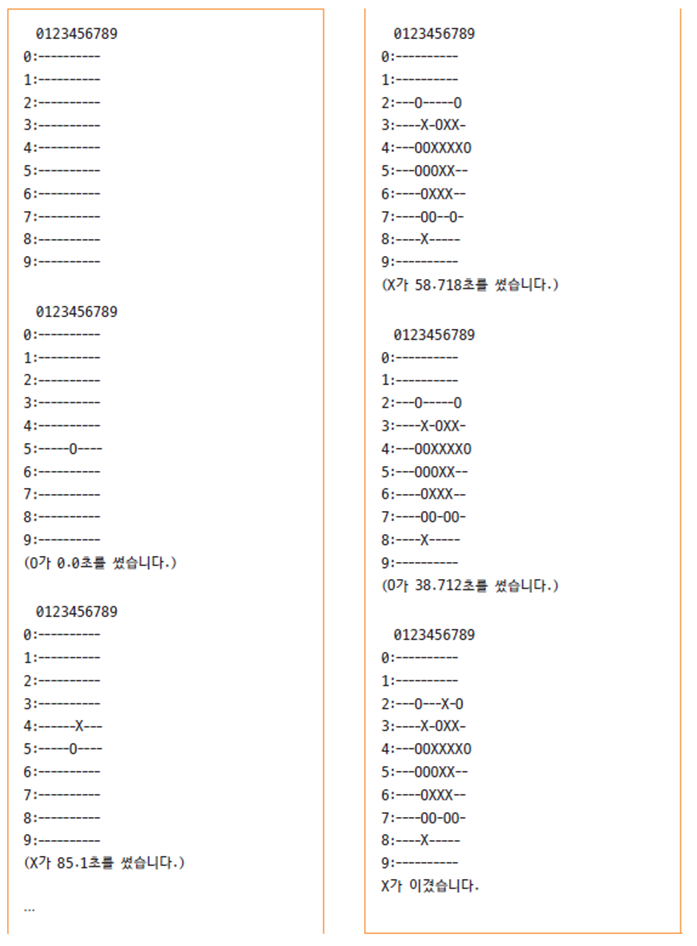